In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df1 = pd.read_excel('附件.xlsx', sheet_name = '表单1')
df2 = pd.read_excel('附件.xlsx', sheet_name = '表单2')
df2 = df2[(df2['成分比例累加和']>= 85) & (df2['成分比例累加和']<= 105)]
df3 = pd.read_excel('附件.xlsx', sheet_name = '表单3')

In [5]:
df1

,文物编号,纹饰,类型,颜色,表面风化
0,1,C,高钾,蓝绿,无风化
1,2,A,铅钡,浅蓝,风化
2,3,A,高钾,蓝绿,无风化
3,4,A,高钾,蓝绿,无风化
4,5,A,高钾,蓝绿,无风化
5,6,A,高钾,蓝绿,无风化
6,7,B,高钾,蓝绿,风化
7,8,C,铅钡,紫,风化
8,9,B,高钾,蓝绿,风化
9,10,B,高钾,蓝绿,风化


In [6]:
df2

,文物采样点,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2),成分比例累加和
0,01,69.33,0.01,9.99,6.32,0.87,3.93,1.74,3.87,0.01,0.01,1.17,0.01,0.01,0.39,97.66
1,02,36.28,0.01,1.05,2.34,1.18,5.73,1.86,0.26,47.43,0.01,3.57,0.19,0.01,0.01,99.93
2,03部位1,87.05,0.01,5.19,2.01,0.01,4.06,0.01,0.78,0.25,0.01,0.66,0.01,0.01,0.01,100.07
3,03部位2,61.71,0.01,12.37,5.87,1.11,5.50,2.16,5.09,1.41,2.86,0.70,0.10,0.01,0.01,98.91
4,04,65.88,0.01,9.67,7.12,1.56,6.44,2.06,2.18,0.01,0.01,0.79,0.01,0.01,0.36,96.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,54严重风化点,17.11,0.01,0.01,0.01,1.11,3.65,0.01,1.34,58.46,0.01,14.13,1.12,0.01,0.01,96.99
65,55,49.01,2.71,0.01,1.13,0.01,1.45,0.01,0.86,32.92,7.95,0.35,0.01,0.01,0.01,96.44
66,56,29.15,0.01,0.01,1.21,0.01,1.85,0.01,0.79,41.25,15.45,2.54,0.01,0.01,0.01,92.31
67,57,25.42,0.01,0.01,1.31,0.01,2.18,0.01,1.16,45.10,17.30,0.01,0.01,0.01,0.01,92.55


In [7]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2
import seaborn as sns
from itertools import combinations
import matplotlib as mpl
# 设置 Matplotlib 中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
sns.set(font='SimHei') # 解决Seaborn中文显示问题

In [8]:
# 查看数据基本信息
print("数据形状:", df1.shape)
print("\n数据列名:", df1.columns.tolist())
print("\n表面风化分布:")
print(df1['表面风化'].value_counts())
print("\n类型分布:")
print(df1['类型'].value_counts())
print("\n纹饰分布:")
print(df1['纹饰'].value_counts())
print("\n颜色分布:")
print(df1['颜色'].value_counts())

数据形状: (58, 5)

数据列名: ['文物编号', '纹饰', '类型', '颜色', '表面风化']

表面风化分布:
表面风化
风化     34
无风化    24
Name: count, dtype: int64

类型分布:
类型
铅钡    40
高钾    18
Name: count, dtype: int64

纹饰分布:
纹饰
C    30
A    22
B     6
Name: count, dtype: int64

颜色分布:
颜色
浅蓝    20
蓝绿    15
深绿     7
紫      4
浅绿     3
深蓝     2
黑      2
绿      1
Name: count, dtype: int64


In [9]:
# 定义卡方检验函数
def chi_square_test(data, var1, var2, alpha=0.05):
    """
    对两个分类变量进行卡方独立性检验
    """
    # 创建列联表
    contingency_table = pd.crosstab(data[var1], data[var2])
    
    # 进行卡方检验
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 计算临界值
    critical_value = chi2.ppf(1 - alpha, dof)
    
    # 计算Cramér's V（效应量）
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1)))
    
    # 输出结果
    print(f"\n=== {var1} 与 {var2} 的关系分析 ===")
    print(f"列联表:")
    print(contingency_table)
    print(f"\n卡方统计量: {chi2_stat:.4f}")
    print(f"自由度: {dof}")
    print(f"p值: {p_value:.6f}")
    print(f"临界值 (α={alpha}): {critical_value:.4f}")
    print(f"Cramér's V (效应量): {cramers_v:.4f}")
    
    if p_value < alpha:
        print(f"结论: 在α={alpha}的显著性水平下，{var1}与{var2}之间存在显著关联 (p < {alpha})")
    else:
        print(f"结论: 在α={alpha}的显著性水平下，{var1}与{var2}之间不存在显著关联 (p >= {alpha})")
    
    # 效应量解释
    if cramers_v < 0.1:
        effect_size = "微弱"
    elif cramers_v < 0.3:
        effect_size = "小"
    elif cramers_v < 0.5:
        effect_size = "中等"
    else:
        effect_size = "强"
    
    print(f"效应量解释: {effect_size}关联")
    
    return {
        'contingency_table': contingency_table,
        'chi2_stat': chi2_stat,
        'p_value': p_value,
        'dof': dof,
        'critical_value': critical_value,
        'cramers_v': cramers_v,
        'significant': p_value < alpha
    }


=== 表面风化 与 类型 的关系分析 ===
列联表:
类型    铅钡  高钾
表面风化        
无风化   12  12
风化    28   6

卡方统计量: 5.4518
自由度: 1
p值: 0.019548
临界值 (α=0.05): 3.8415
Cramér's V (效应量): 0.3066
结论: 在α=0.05的显著性水平下，表面风化与类型之间存在显著关联 (p < 0.05)
效应量解释: 中等关联


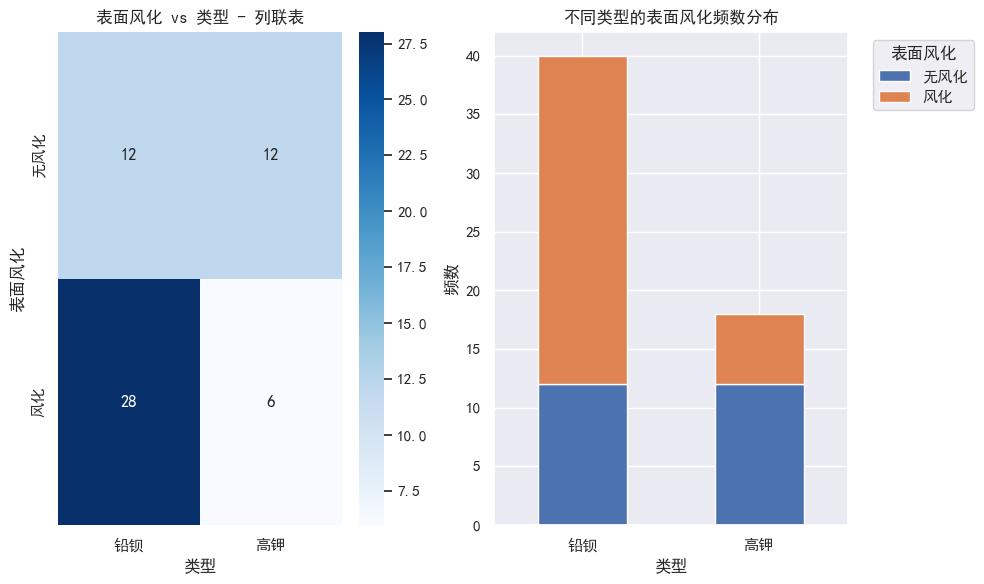

In [10]:
# 1. 分析表面风化与玻璃类型的关系
result1 = chi_square_test(df1, '表面风化', '类型')

# 可视化列联表
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
contingency_table_1 = pd.crosstab(df1['表面风化'], df1['类型'])
sns.heatmap(contingency_table_1, annot=True, fmt='d', cmap='Blues')
plt.title('表面风化 vs 类型 - 列联表')
plt.ylabel('表面风化')
plt.xlabel('类型')

# 绘制堆叠条形图 - 修改为频数图
plt.subplot(1, 2, 2)
contingency_table_1_freq = pd.crosstab(df1['类型'], df1['表面风化'])
contingency_table_1_freq.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('不同类型的表面风化频数分布')
plt.ylabel('频数')
plt.xlabel('类型')
plt.legend(title='表面风化', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== 表面风化 与 纹饰 的关系分析 ===
列联表:
纹饰     A  B   C
表面风化           
无风化   11  0  13
风化    11  6  17

卡方统计量: 4.9565
自由度: 2
p值: 0.083888
临界值 (α=0.05): 5.9915
Cramér's V (效应量): 0.2923
结论: 在α=0.05的显著性水平下，表面风化与纹饰之间不存在显著关联 (p >= 0.05)
效应量解释: 小关联


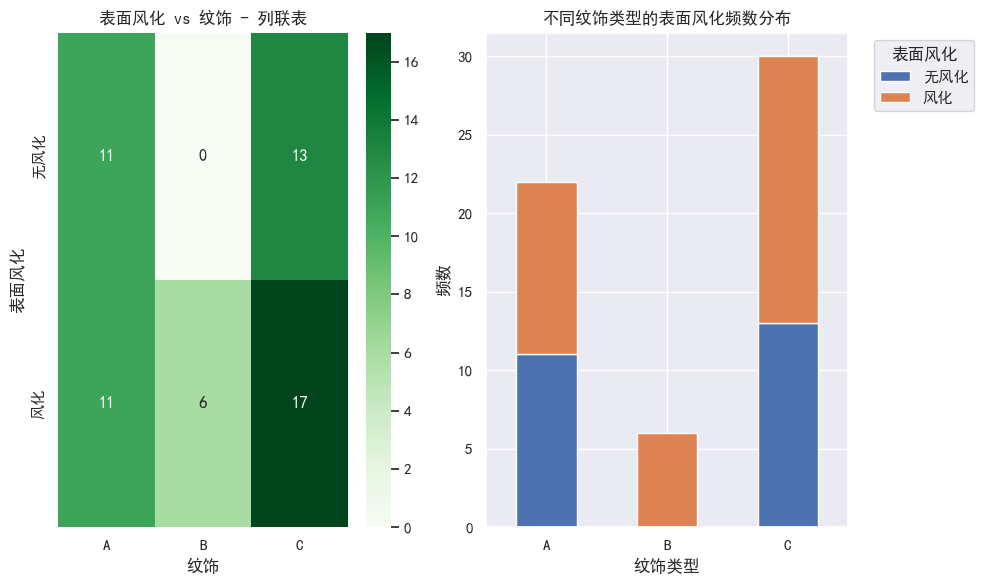

In [11]:
# 2. 分析表面风化与纹饰的关系
result2 = chi_square_test(df1, '表面风化', '纹饰')

# 可视化列联表
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
contingency_table_2 = pd.crosstab(df1['表面风化'], df1['纹饰'])
sns.heatmap(contingency_table_2, annot=True, fmt='d', cmap='Greens')
plt.title('表面风化 vs 纹饰 - 列联表')
plt.ylabel('表面风化')
plt.xlabel('纹饰')

# 绘制堆叠条形图 - 修改为频数图
plt.subplot(1, 2, 2)
contingency_table_2_freq = pd.crosstab(df1['纹饰'], df1['表面风化'])
contingency_table_2_freq.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('不同纹饰类型的表面风化频数分布')
plt.ylabel('频数')
plt.xlabel('纹饰类型')
plt.legend(title='表面风化', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== 表面风化 与 颜色 的关系分析 ===
列联表:
颜色    浅绿  浅蓝  深绿  深蓝  紫  绿  蓝绿  黑
表面风化                             
无风化    2   8   3   2  2  1   6  0
风化     1  12   4   0  2  0   9  2

卡方统计量: 6.2871
自由度: 7
p值: 0.506650
临界值 (α=0.05): 14.0671
Cramér's V (效应量): 0.3412
结论: 在α=0.05的显著性水平下，表面风化与颜色之间不存在显著关联 (p >= 0.05)
效应量解释: 中等关联


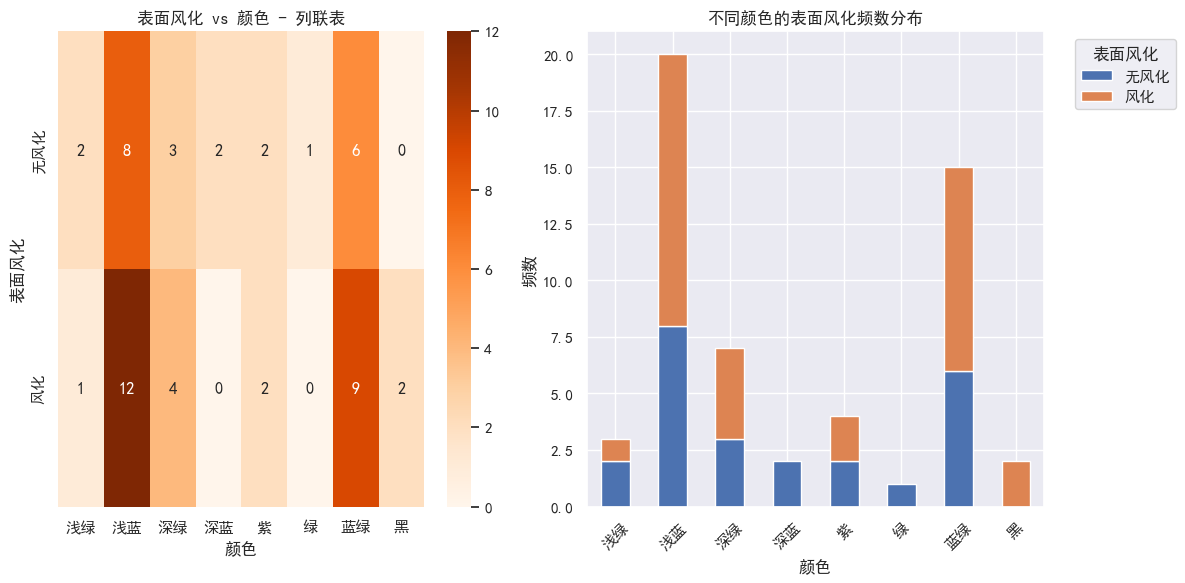

In [12]:
# 3. 分析表面风化与颜色的关系
result3 = chi_square_test(df1, '表面风化', '颜色')

# 可视化列联表
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
contingency_table_3 = pd.crosstab(df1['表面风化'], df1['颜色'])
sns.heatmap(contingency_table_3, annot=True, fmt='d', cmap='Oranges')
plt.title('表面风化 vs 颜色 - 列联表')
plt.ylabel('表面风化')
plt.xlabel('颜色')

# 绘制堆叠条形图 - 修改为频数图
plt.subplot(1, 2, 2)
contingency_table_3_freq = pd.crosstab(df1['颜色'], df1['表面风化'])
contingency_table_3_freq.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('不同颜色的表面风化频数分布')
plt.ylabel('频数')
plt.xlabel('颜色')
plt.legend(title='表面风化', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# 4. 综合分析报告
print("=" * 60)
print("                    综合分析报告")
print("=" * 60)

# 创建结果汇总表
results_summary = pd.DataFrame({
    '关联关系': ['表面风化 vs 类型', '表面风化 vs 纹饰', '表面风化 vs 颜色'],
    '卡方统计量': [result1['chi2_stat'], result2['chi2_stat'], result3['chi2_stat']],
    'p值': [result1['p_value'], result2['p_value'], result3['p_value']],
    'Cramér\'s V': [result1['cramers_v'], result2['cramers_v'], result3['cramers_v']],
    '是否显著': [result1['significant'], result2['significant'], result3['significant']]
})

print(results_summary.round(6))

print("\n结论总结:")
for i, relationship in enumerate(['表面风化与类型', '表面风化与纹饰', '表面风化与颜色']):
    result = [result1, result2, result3][i]
    if result['significant']:
        print(f"• {relationship}: 存在显著关联 (p = {result['p_value']:.6f} < 0.05)")
    else:
        print(f"• {relationship}: 不存在显著关联 (p = {result['p_value']:.6f} >= 0.05)")

print("\n效应量说明:")
print("• Cramér's V < 0.1: 微弱关联")
print("• 0.1 ≤ Cramér's V < 0.3: 小关联") 
print("• 0.3 ≤ Cramér's V < 0.5: 中等关联")
print("• Cramér's V ≥ 0.5: 强关联")

                    综合分析报告
         关联关系     卡方统计量        p值  Cramér's V   是否显著
0  表面风化 vs 类型  5.451814  0.019548    0.306589   True
1  表面风化 vs 纹饰  4.956536  0.083888    0.292331  False
2  表面风化 vs 颜色  6.287143  0.506650    0.341216  False

结论总结:
• 表面风化与类型: 存在显著关联 (p = 0.019548 < 0.05)
• 表面风化与纹饰: 不存在显著关联 (p = 0.083888 >= 0.05)
• 表面风化与颜色: 不存在显著关联 (p = 0.506650 >= 0.05)

效应量说明:
• Cramér's V < 0.1: 微弱关联
• 0.1 ≤ Cramér's V < 0.3: 小关联
• 0.3 ≤ Cramér's V < 0.5: 中等关联
• Cramér's V ≥ 0.5: 强关联


In [14]:
# 5. 进一步分析：残差分析
def residual_analysis(data, var1, var2):
    """
    进行残差分析，找出哪些组合对卡方统计量贡献最大
    """
    contingency_table = pd.crosstab(data[var1], data[var2])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 计算标准化残差
    observed = contingency_table.values
    residuals = (observed - expected) / np.sqrt(expected)
    
    # 创建残差DataFrame
    residuals_df = pd.DataFrame(residuals, 
                               index=contingency_table.index, 
                               columns=contingency_table.columns)
    
    print(f"\n=== {var1} vs {var2} 标准化残差分析 ===")
    print("标准化残差矩阵:")
    print(residuals_df.round(3))
    print("\n残差解释:")
    print("• |残差| > 2: 该组合对卡方统计量有显著贡献")
    print("• 正残差: 观察频数大于期望频数")
    print("• 负残差: 观察频数小于期望频数")
    
    # 找出显著的残差
    significant_residuals = []
    for i in range(residuals_df.shape[0]):
        for j in range(residuals_df.shape[1]):
            if abs(residuals_df.iloc[i, j]) > 2:
                significant_residuals.append({
                    f'{var1}': residuals_df.index[i],
                    f'{var2}': residuals_df.columns[j],
                    '标准化残差': residuals_df.iloc[i, j],
                    '观察频数': observed[i, j],
                    '期望频数': expected[i, j]
                })
    
    if significant_residuals:
        print(f"\n显著的组合 (|残差| > 2):")
        sig_df = pd.DataFrame(significant_residuals)
        print(sig_df.round(3))
    else:
        print("\n没有发现显著的残差组合")
    
    return residuals_df

# 对三个关系进行残差分析
residuals1 = residual_analysis(df1, '表面风化', '类型')
residuals2 = residual_analysis(df1, '表面风化', '纹饰') 
residuals3 = residual_analysis(df1, '表面风化', '颜色')


=== 表面风化 vs 类型 标准化残差分析 ===
标准化残差矩阵:
类型       铅钡     高钾
表面风化              
无风化  -1.119  1.668
风化    0.940 -1.401

残差解释:
• |残差| > 2: 该组合对卡方统计量有显著贡献
• 正残差: 观察频数大于期望频数
• 负残差: 观察频数小于期望频数

没有发现显著的残差组合

=== 表面风化 vs 纹饰 标准化残差分析 ===
标准化残差矩阵:
纹饰        A      B      C
表面风化                     
无风化   0.629 -1.576  0.166
风化   -0.528  1.324 -0.140

残差解释:
• |残差| > 2: 该组合对卡方统计量有显著贡献
• 正残差: 观察频数大于期望频数
• 负残差: 观察频数小于期望频数

没有发现显著的残差组合

=== 表面风化 vs 颜色 标准化残差分析 ===
标准化残差矩阵:
颜色       浅绿     浅蓝     深绿     深蓝      紫      绿     蓝绿      黑
表面风化                                                        
无风化   0.577 -0.298 -0.063  1.179  0.167  0.833 -0.258 -0.943
风化   -0.516  0.267  0.056 -1.054 -0.149 -0.745  0.231  0.843

残差解释:
• |残差| > 2: 该组合对卡方统计量有显著贡献
• 正残差: 观察频数大于期望频数
• 负残差: 观察频数小于期望频数

没有发现显著的残差组合


In [15]:
# 对 df2 数据进行 CLR 中心对数比变换
from scipy.stats import gmean
import numpy as np

# 确定需要进行变换的成分列
# 这里排除了标识列和成分比例累加和列
composition_cols = [col for col in df2.columns if col not in ['文物采样点', '成分比例累加和']]
composition_data = df2[composition_cols].copy()

# CLR变换要求所有值为正数。用一个极小的数替换零值。
composition_data.replace(0, 1e-9, inplace=True)

# 定义并应用CLR变换
def clr_transform(data):
    """对成分数据进行中心对数比(CLR)变换"""
    # 按行计算几何平均数
    gmean_vals = gmean(data, axis=1)
    # 计算CLR变换值: log(x_i / g(x))
    # 使用 .div(gmean_vals, axis=0) 将每行除以其对应的几何平均数
    clr_data = np.log(data.div(gmean_vals, axis=0))
    return clr_data

# 应用变换
df2_clr = clr_transform(composition_data)

# 将文物编号和采样点等标识信息加回到变换后的DataFrame中
# Pandas会根据索引自动对齐数据
df2_clr['文物采样点'] = df2['文物采样点']

# 调整列的顺序，将标识列放在最前面，方便查看
id_cols = ['文物采样点']
data_cols = [col for col in df2_clr.columns if col not in id_cols]
df2_clr = df2_clr[id_cols + data_cols]

print("CLR变换后的数据 (df2_clr) 前5行:")
df2_clr.head()

CLR变换后的数据 (df2_clr) 前5行:


,文物采样点,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,01,5.116718,-3.727330,3.179424,2.721559,0.738578,2.246479,1.431725,2.231094,-3.727330,-3.727330,1.034844,-3.727330,-3.727330,-0.063769
1,02,4.253742,-3.942695,0.711265,1.512626,0.827990,2.408191,1.283052,-0.684599,4.521730,-3.942695,1.935041,-0.998256,-3.942695,-3.942695
2,03部位1,6.328906,-2.742747,3.509157,2.560558,-2.742747,3.263606,-2.742747,1.613962,0.476129,-2.742747,1.446908,-2.742747,-2.742747,-2.742747
3,03部位2,4.298610,-4.429007,2.691438,1.946018,0.280524,1.880912,0.946272,1.803441,0.519753,1.226985,-0.180511,-2.126422,-4.429007,-4.429007
4,04,5.048850,-3.744155,3.130043,2.823923,1.305701,2.723543,1.583721,1.640340,-3.744155,-3.744155,0.625293,-3.744155,-3.744155,-0.160636


In [16]:
# 步骤 1: 修正并合并数据
# 从 df2 的 '文物采样点' 中提取纯数字的 '文物编号'
# 使用正则表达式 .str.extract(r'^(\d+)') 提取字符串开头的数字部分
df2_clr['文物编号'] = df2['文物采样点'].astype(str).str.extract(r'^(\d+)').iloc[:, 0]

# 从 df1 中选取我们需要的列
df1_info = df1[['文物编号', '类型', '表面风化']].copy()

# 确保两个DataFrame用于合并的键匹配正确
df2_clr['文物编号'] = df2_clr['文物编号'].astype(int)

# 使用修正后的 '文物编号' 作为键，将 df1_info 合并到 df2_clr 中
analysis_df = pd.merge(df2_clr, df1_info, on='文物编号', how='left')

analysis_df

,文物采样点,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2),文物编号,类型,表面风化
0,01,5.116718,-3.727330,3.179424,2.721559,0.738578,2.246479,1.431725,2.231094,-3.727330,-3.727330,1.034844,-3.727330,-3.727330,-0.063769,1,高钾,无风化
1,02,4.253742,-3.942695,0.711265,1.512626,0.827990,2.408191,1.283052,-0.684599,4.521730,-3.942695,1.935041,-0.998256,-3.942695,-3.942695,2,铅钡,风化
2,03部位1,6.328906,-2.742747,3.509157,2.560558,-2.742747,3.263606,-2.742747,1.613962,0.476129,-2.742747,1.446908,-2.742747,-2.742747,-2.742747,3,高钾,无风化
3,03部位2,4.298610,-4.429007,2.691438,1.946018,0.280524,1.880912,0.946272,1.803441,0.519753,1.226985,-0.180511,-2.126422,-4.429007,-4.429007,3,高钾,无风化
4,04,5.048850,-3.744155,3.130043,2.823923,1.305701,2.723543,1.583721,1.640340,-3.744155,-3.744155,0.625293,-3.744155,-3.744155,-0.160636,4,高钾,无风化
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,54严重风化点,4.330720,-3.114113,-3.114113,-3.114113,1.595417,2.785784,-3.114113,1.783727,5.559400,-3.114113,4.139357,1.604386,-3.114113,-3.114113,54,铅钡,风化
63,55,5.169286,2.274210,-3.327909,1.399479,-3.327909,1.648825,-3.327909,1.126439,4.771342,3.350433,0.227439,-3.327909,-3.327909,-3.327909,55,铅钡,无风化
64,56,4.865614,-3.112011,-3.112011,1.683780,-3.112011,2.108345,-3.112011,1.257437,5.212810,4.230768,2.425323,-3.112011,-3.112011,-3.112011,56,铅钡,风化
65,57,5.074712,-2.765994,-2.765994,2.109203,-2.765994,2.618501,-2.765994,1.987596,5.648058,4.689883,-2.765994,-2.765994,-2.765994,-2.765994,57,铅钡,风化


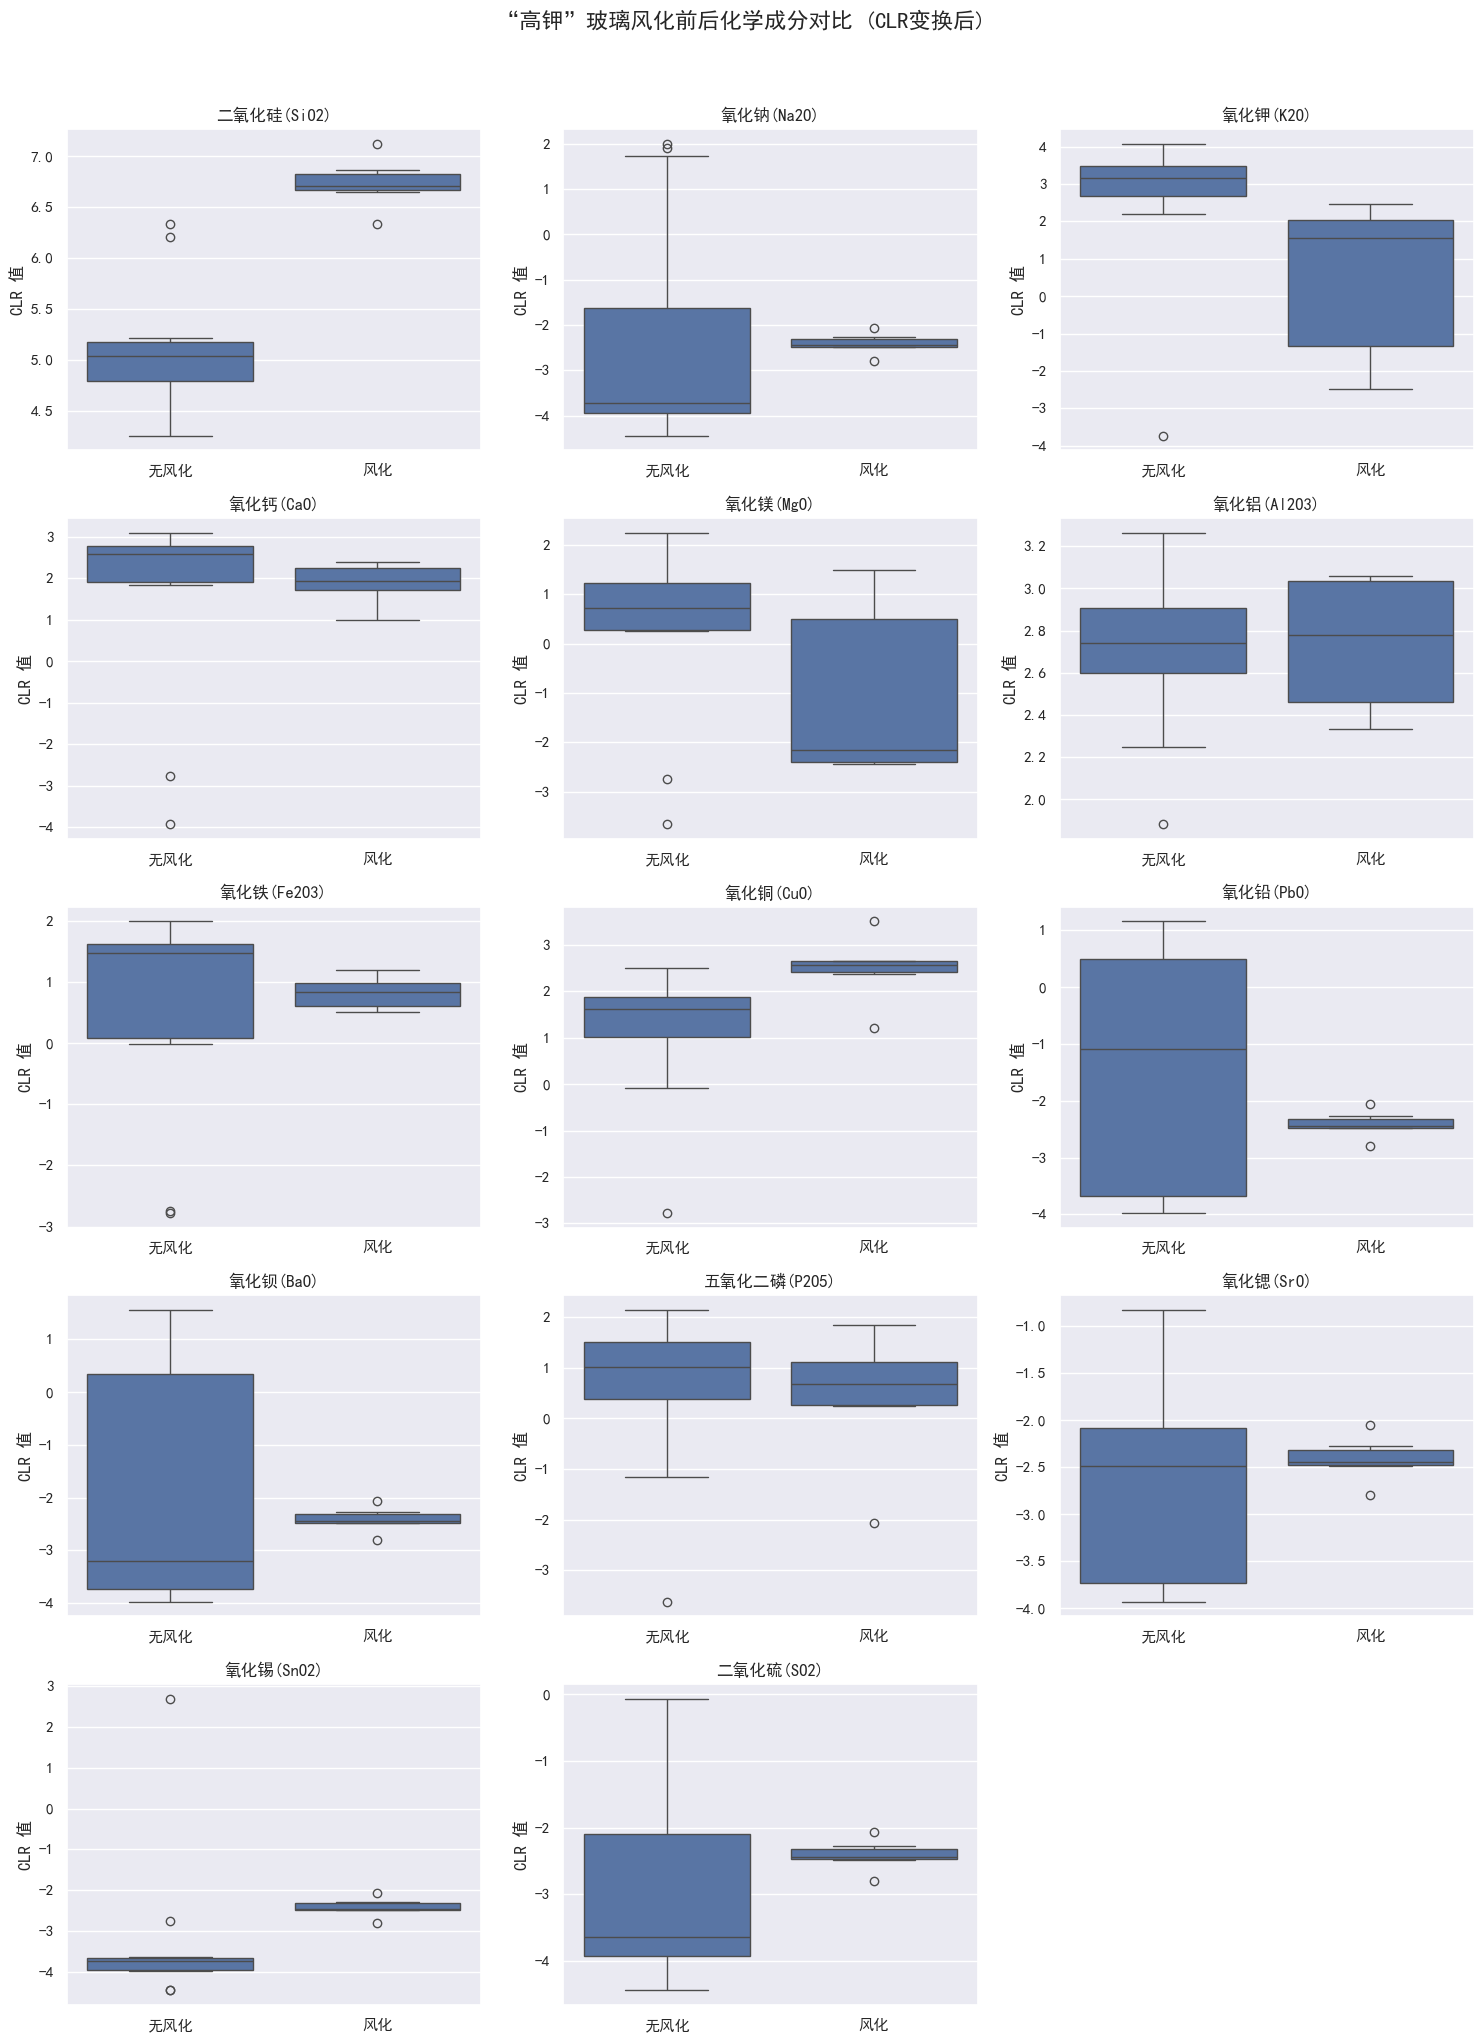

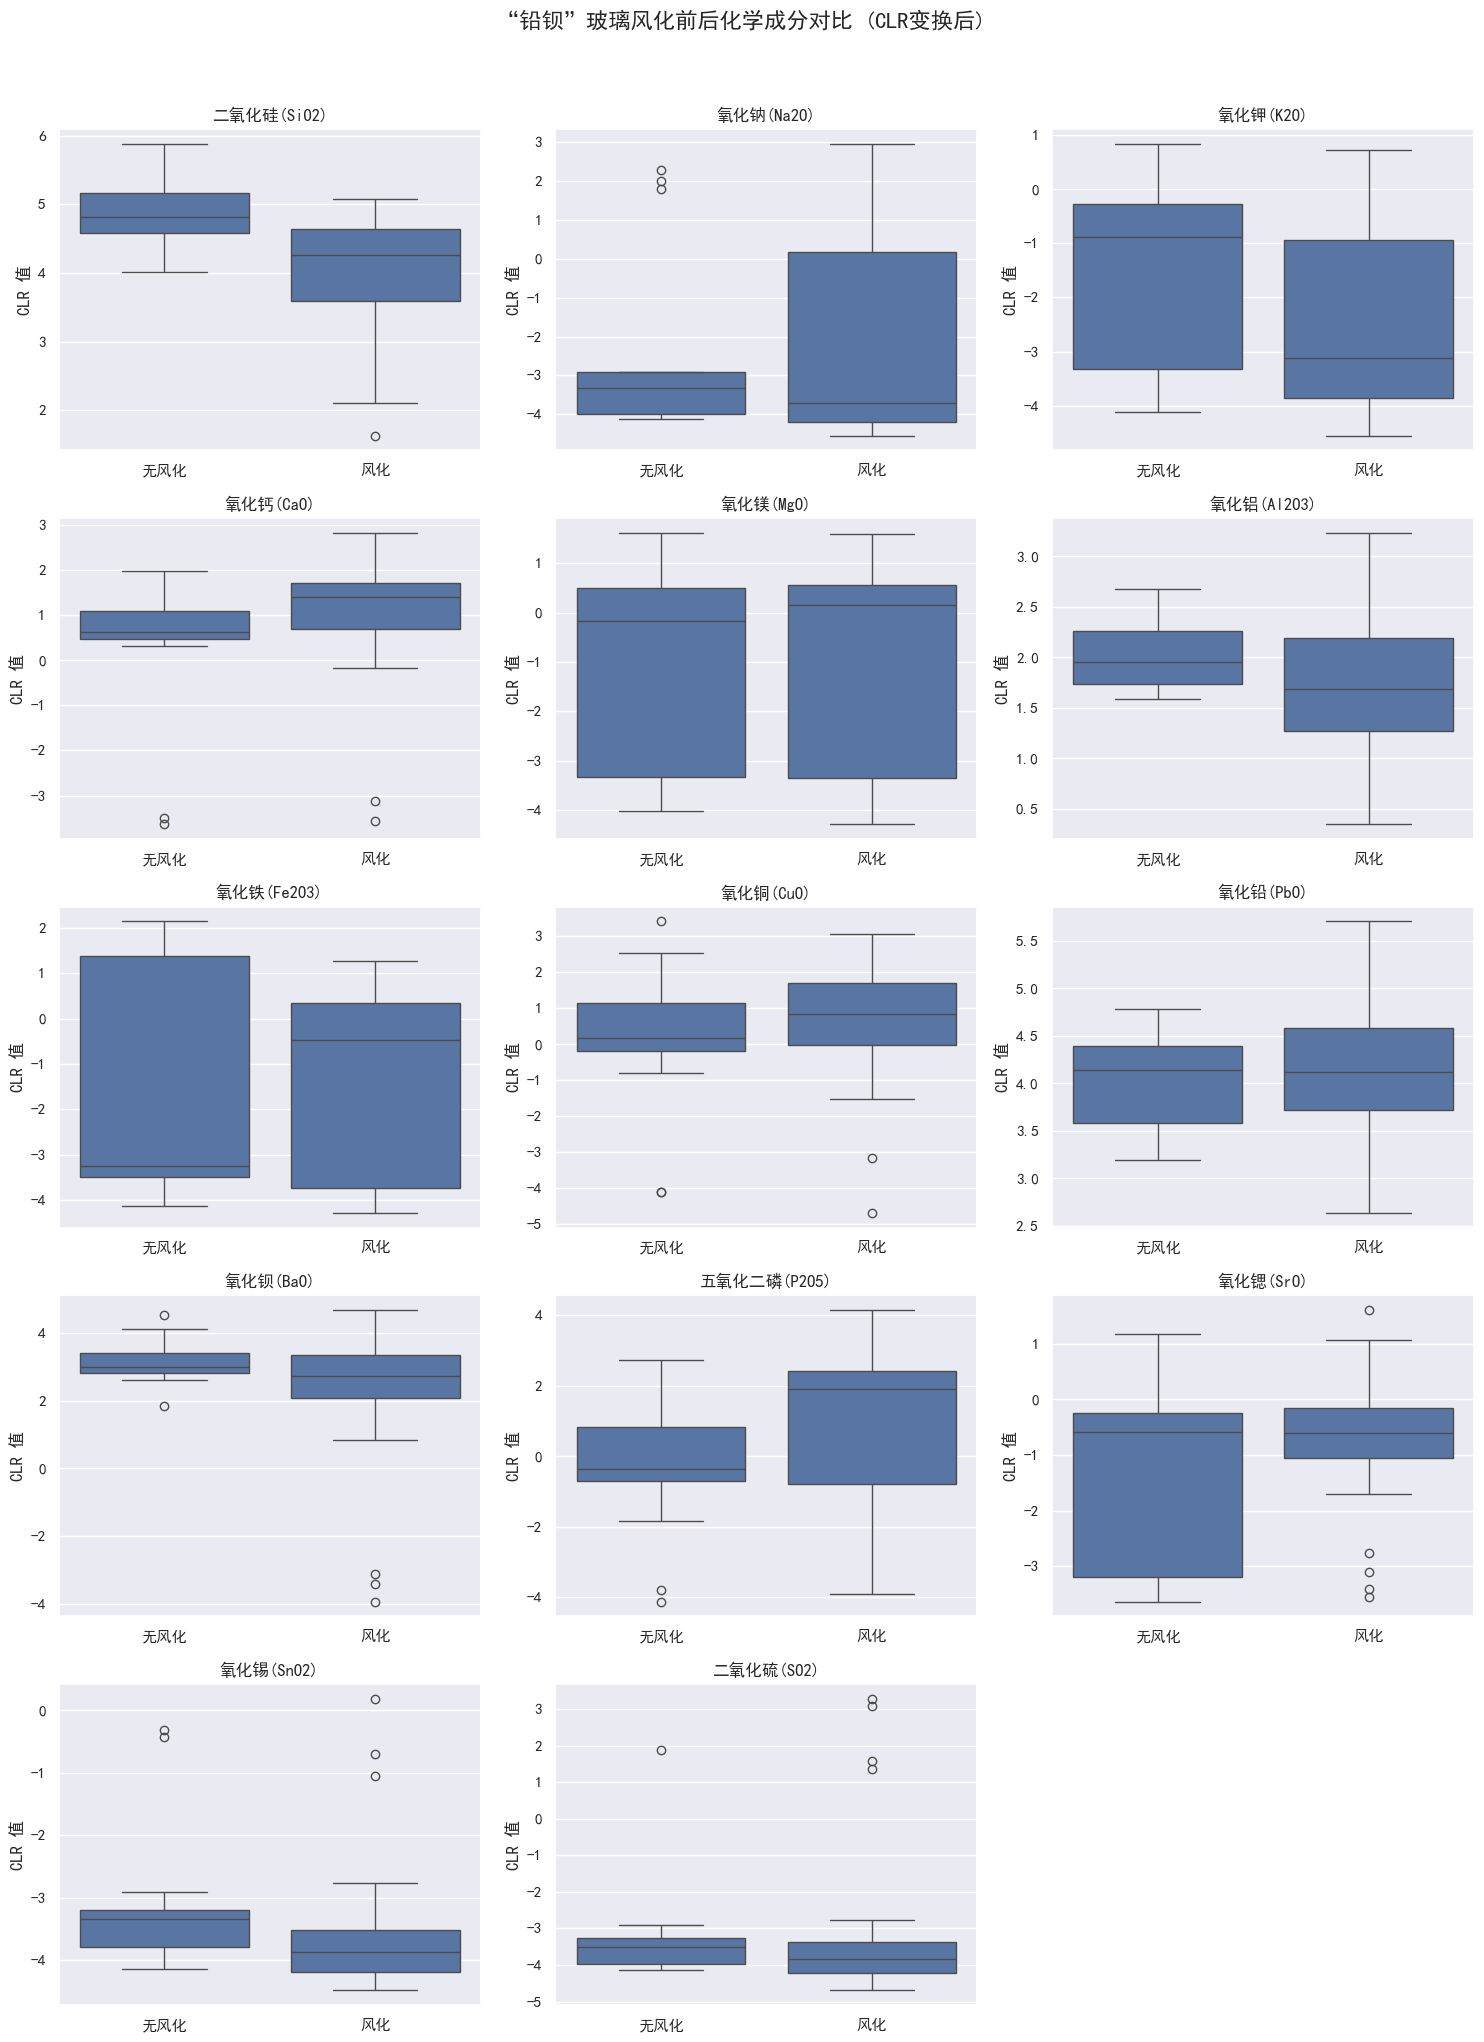

In [17]:
# 步骤 2: 数据可视化 (箱线图)
# --------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# 获取所有玻璃类型
glass_types = analysis_df['类型'].unique()

# 为每种玻璃类型生成图表
for glass_type in glass_types:
    # 筛选出当前类型的玻璃数据
    df_type = analysis_df[analysis_df['类型'] == glass_type]
    
    # 计算需要的行数和列数
    n_cols = 3
    n_rows = (len(composition_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    fig.suptitle(f'“{glass_type}”玻璃风化前后化学成分对比 (CLR变换后)', fontsize=16, y=1.02)

    # 将多维axes数组展平为一维，方便遍历
    axes = axes.flatten()
    
    for i, component in enumerate(composition_cols):
        sns.boxplot(x='表面风化', y=component, data=df_type, ax=axes[i], order=['无风化', '风化'])
        axes[i].set_title(component)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('CLR 值')
        
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

In [18]:
# 步骤 3: 统计检验 (Mann-Whitney U 检验)
# ---------------------------------------
from scipy.stats import mannwhitneyu

# 创建一个空的DataFrame来存储检验结果
results = []

# 对每种玻璃类型进行分析
for glass_type in glass_types:
    # 对每种化学成分进行分析
    for component in composition_cols:
        # 筛选数据
        df_type = analysis_df[analysis_df['类型'] == glass_type]
        
        # 分离出“风化”和“无风化”的数据
        weathered = df_type[df_type['表面风化'] == '风化'][component].dropna()
        unweathered = df_type[df_type['表面风化'] == '无风化'][component].dropna()
        
        # 只有当两组都有数据时才进行检验
        if len(weathered) > 1 and len(unweathered) > 1:
            stat, p_value = mannwhitneyu(weathered, unweathered, alternative='two-sided')
            
            results.append({
                '玻璃类型': glass_type,
                '化学成分': component,
                'p值': p_value,
                '是否显著 (p<0.05)': '是' if p_value < 0.05 else '否'
            })

# 将结果转换为DataFrame并显示
results_df = pd.DataFrame(results)

print("风化前后化学成分差异的显著性检验结果 (Mann-Whitney U 检验):")
display(results_df)

风化前后化学成分差异的显著性检验结果 (Mann-Whitney U 检验):


,玻璃类型,化学成分,p值,是否显著 (p<0.05)
0,高钾,二氧化硅(SiO2),0.000108,是
1,高钾,氧化钠(Na2O),0.150506,否
2,高钾,氧化钾(K2O),0.004740,是
3,高钾,氧化钙(CaO),0.102456,否
4,高钾,氧化镁(MgO),0.616462,否
5,高钾,氧化铝(Al2O3),0.963585,否
6,高钾,氧化铁(Fe2O3),0.384508,否
7,高钾,氧化铜(CuO),0.009696,是
8,高钾,氧化铅(PbO),0.553221,否
9,高钾,氧化钡(BaO),0.384508,否


In [19]:
# 步骤 1: 准备建模数据
# --------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 筛选出表面无风化的、类型为“高钾”或“铅钡”的样本
model_df = analysis_df[
    (analysis_df['表面风化'] == '无风化') &
    (analysis_df['类型'].isin(['高钾', '铅钡']))
].copy()

print(f"用于建模的样本数量: {len(model_df)}")
print("\n各类样本数量分布:")
print(model_df['类型'].value_counts())

# 定义特征 (X) 和目标 (y)
# 特征是所有化学成分列
features = [col for col in model_df.columns if col not in ['文物编号', '文物采样点', '类型', '表面风化']]
X = model_df[features]
y = model_df['类型']

# 将目标变量（“高钾”、“铅钡”）编码为数字（0, 1）
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 记住编码的对应关系，方便后续解释
# le.classes_ 会显示 ['高钾', '铅钡']，意味着 高钾->0, 铅钡->1
print("\n目标变量编码关系:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name} -> {i}")


# 将数据划分为训练集和测试集 (80% 训练, 20% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

用于建模的样本数量: 25

各类样本数量分布:
类型
铅钡    13
高钾    12
Name: count, dtype: int64

目标变量编码关系:
  铅钡 -> 0
  高钾 -> 1

训练集大小: 20
测试集大小: 5


模型在测试集上的准确率: 80.00%

分类报告:
              precision    recall  f1-score   support

          铅钡       0.75      1.00      0.86         3
          高钾       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5


分类报告:
              precision    recall  f1-score   support

          铅钡       0.75      1.00      0.86         3
          高钾       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



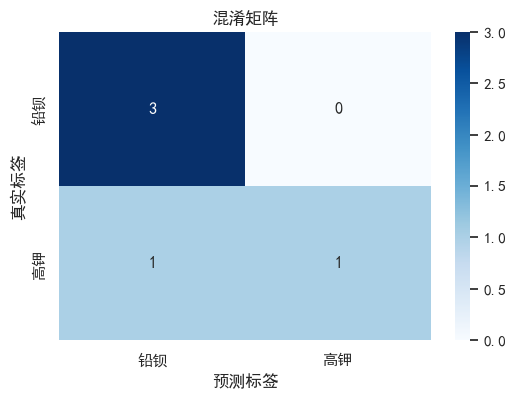

In [20]:
# 步骤 2: 训练决策树模型并评估
# --------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# 初始化并训练决策树模型
# max_depth=3 限制树的深度以防过拟合，并使规则更简洁
dt_classifier = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_classifier.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = dt_classifier.predict(X_test)

# 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
print(f"模型在测试集上的准确率: {accuracy:.2%}\n")

print("分类报告:")
# target_names=le.classes_ 可以让报告显示原始标签
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 可视化混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

决策树分类规则:
|--- 氧化钾(K2O) <= 1.51
|   |--- class: 0
|--- 氧化钾(K2O) >  1.51
|   |--- class: 1


规则解读提示:
• value 表示落入该节点的样本分布，例如 [10, 2] 表示有10个“高钾”和2个“铅钡”。
• class 表示该节点最终判定的类别。


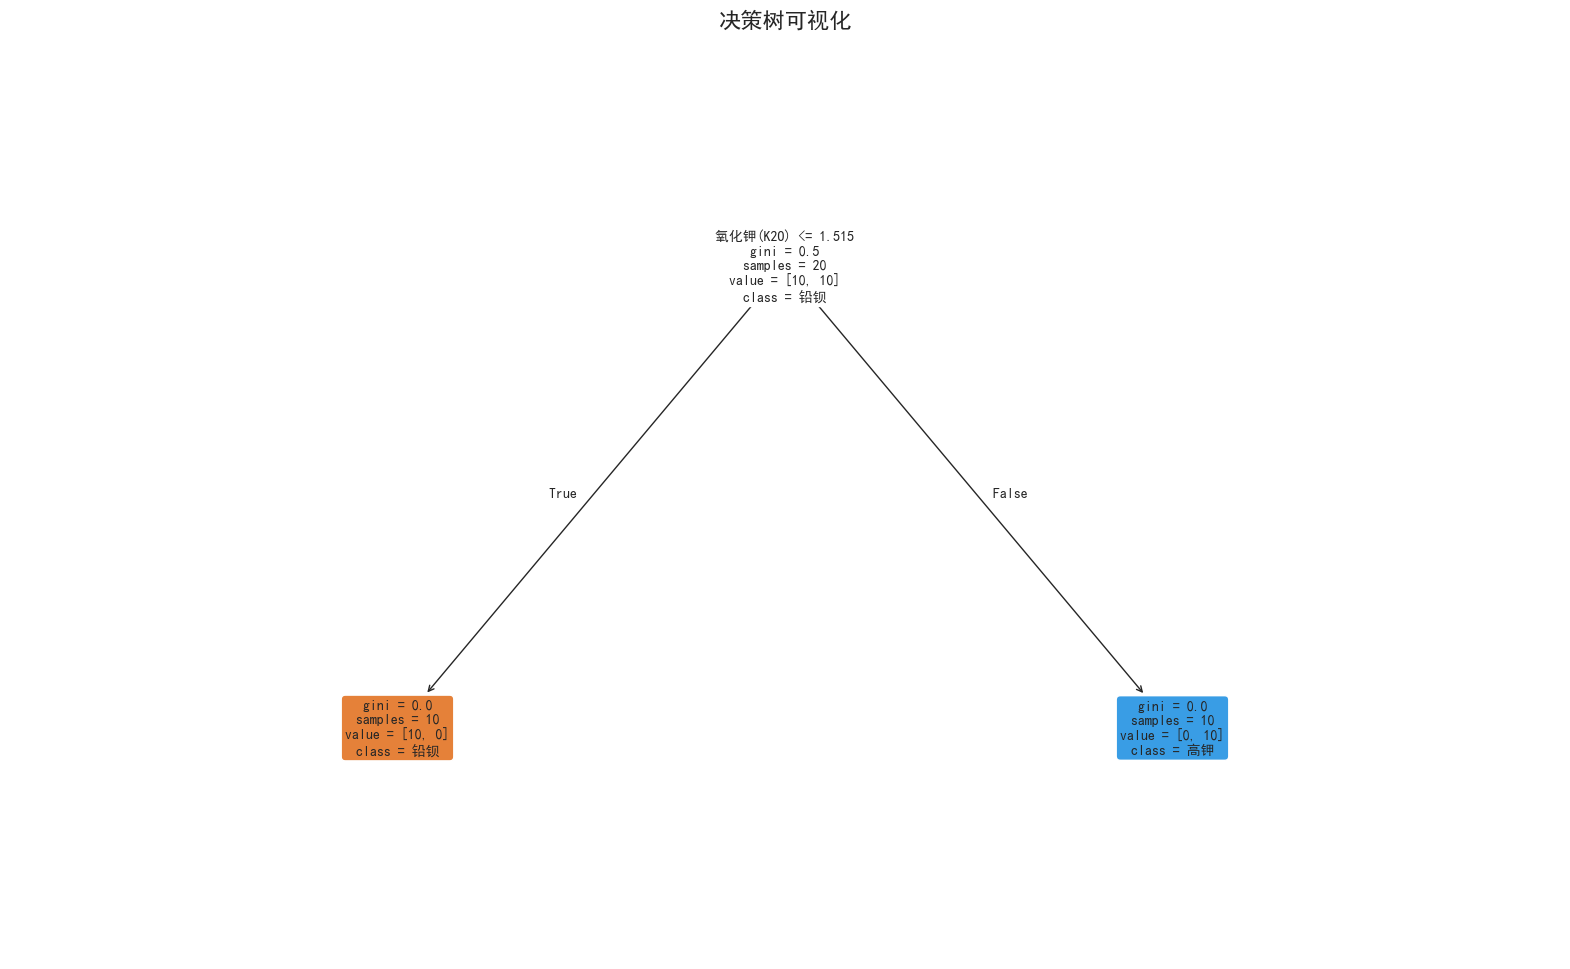

In [21]:
# 步骤 3: 提取并可视化分类规则
# --------------------------------
from sklearn.tree import export_text, plot_tree

# 提取文本格式的决策规则
# feature_names=features 可以让规则显示化学成分名称
tree_rules = export_text(dt_classifier, feature_names=features)

print("="*60)
print("决策树分类规则:")
print("="*60)
print(tree_rules)
print("\n规则解读提示:")
print("• value 表示落入该节点的样本分布，例如 [10, 2] 表示有10个“高钾”和2个“铅钡”。")
print("• class 表示该节点最终判定的类别。")


# 可视化决策树
plt.figure(figsize=(20, 12))
plot_tree(dt_classifier, 
          feature_names=features, 
          class_names=le.classes_, 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("决策树可视化", fontsize=16)
plt.show()

线性SVM模型在测试集上的准确率: 80.00%

分类报告:
              precision    recall  f1-score   support

          铅钡       0.75      1.00      0.86         3
          高钾       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

              precision    recall  f1-score   support

          铅钡       0.75      1.00      0.86         3
          高钾       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



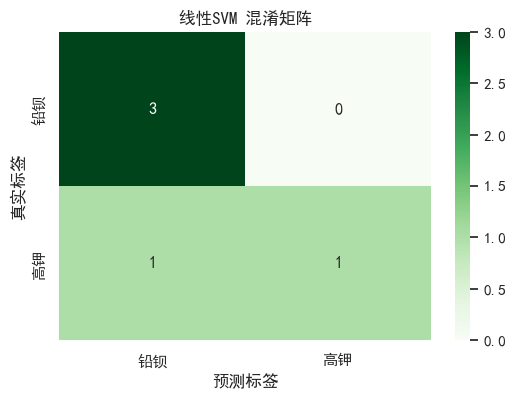

In [22]:
# 步骤 4: 训练线性SVM模型并评估
# --------------------------------
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 创建一个包含“标准化”和“线性SVM”的管道
# 标准化是使用SVM前的标准操作，可以提高模型性能
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(random_state=42, dual=False)) # dual=False 推荐在样本>特征时使用
])

# 使用训练数据训练整个管道
svm_pipeline.fit(X_train, y_train)

# 在测试集上进行预测
y_pred_svm = svm_pipeline.predict(X_test)

# 评估模型性能
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"线性SVM模型在测试集上的准确率: {accuracy_svm:.2%}\n")

print("分类报告:")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# 可视化混淆矩阵
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('线性SVM 混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

线性SVM模型学习到的特征权重:
           化学成分   系数 (权重)  重要性 (绝对值)
2      氧化钾(K2O)  0.465338   0.465338
8      氧化铅(PbO) -0.368808   0.368808
4      氧化镁(MgO)  0.312375   0.312375
9      氧化钡(BaO) -0.270616   0.270616
7      氧化铜(CuO)  0.173166   0.173166
3      氧化钙(CaO)  0.153925   0.153925
1     氧化钠(Na2O) -0.128519   0.128519
12    氧化锡(SnO2) -0.112337   0.112337
13    二氧化硫(SO2) -0.073552   0.073552
5    氧化铝(Al2O3)  0.070509   0.070509
10  五氧化二磷(P2O5)  0.047223   0.047223
0    二氧化硅(SiO2)  0.023850   0.023850
11     氧化锶(SrO) -0.007850   0.007850
6    氧化铁(Fe2O3) -0.001143   0.001143


D:\TEMP\USER_TEMP\ipykernel_28648\899446489.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='系数 (权重)', y='化学成分', data=feature_importance, palette='vlag')


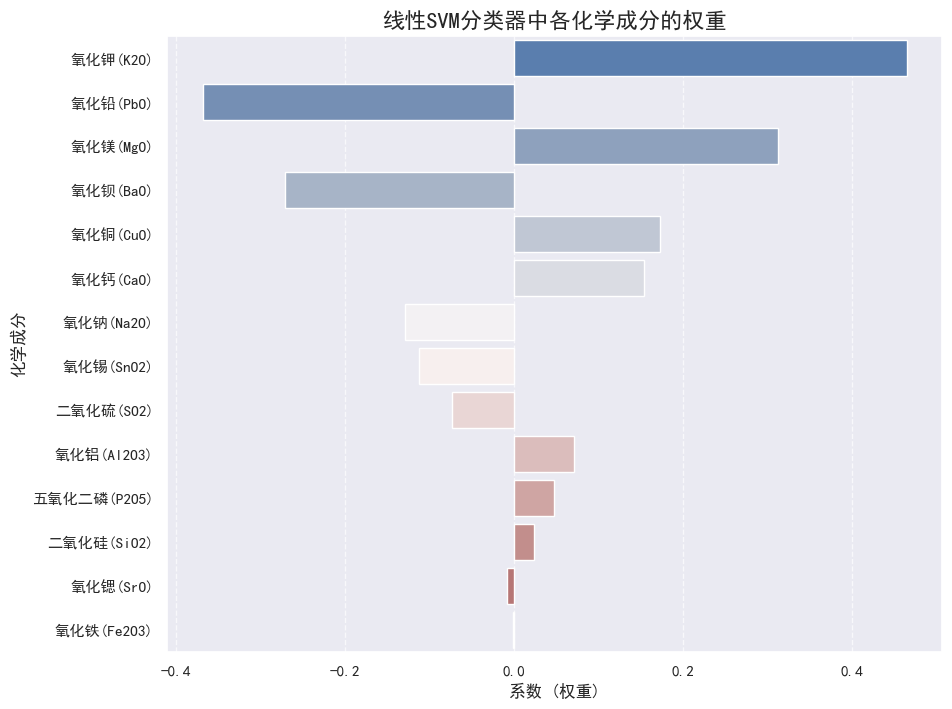


规则解读提示:
• 正系数 (红色) 将分类推向 '高钾' 类。
• 负系数 (蓝色) 将分类推向 '铅钡' 类。
• 系数的绝对值越大，该成分对于区分这两种玻璃的作用就越强。


In [23]:
# 步骤 5: 提取并解释SVM的分类规则
# ------------------------------------

# 从管道中提取训练好的SVM模型
svm_model = svm_pipeline.named_steps['svc']

# 获取模型为每个特征学习到的系数
coefficients = svm_model.coef_[0]

# 创建一个DataFrame来展示特征及其对应的系数
feature_importance = pd.DataFrame({
    '化学成分': features,
    '系数 (权重)': coefficients
})

# 根据系数的绝对值进行排序，找出最重要的特征
feature_importance['重要性 (绝对值)'] = feature_importance['系数 (权重)'].abs()
feature_importance = feature_importance.sort_values(by='重要性 (绝对值)', ascending=False)

print("="*60)
print("线性SVM模型学习到的特征权重:")
print("="*60)
print(feature_importance)

# 可视化特征权重
plt.figure(figsize=(10, 8))
sns.barplot(x='系数 (权重)', y='化学成分', data=feature_importance, palette='vlag')
plt.title('线性SVM分类器中各化学成分的权重', fontsize=16)
plt.xlabel('系数 (权重)')
plt.ylabel('化学成分')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n规则解读提示:")
# 回忆一下: 0 -> 高钾, 1 -> 铅钡
print(f"• 正系数 (红色) 将分类推向 '{le.classes_[1]}' 类。")
print(f"• 负系数 (蓝色) 将分类推向 '{le.classes_[0]}' 类。")
print("• 系数的绝对值越大，该成分对于区分这两种玻璃的作用就越强。")


--- “高钾”玻璃各化学成分分布 (CLR变换后) ---


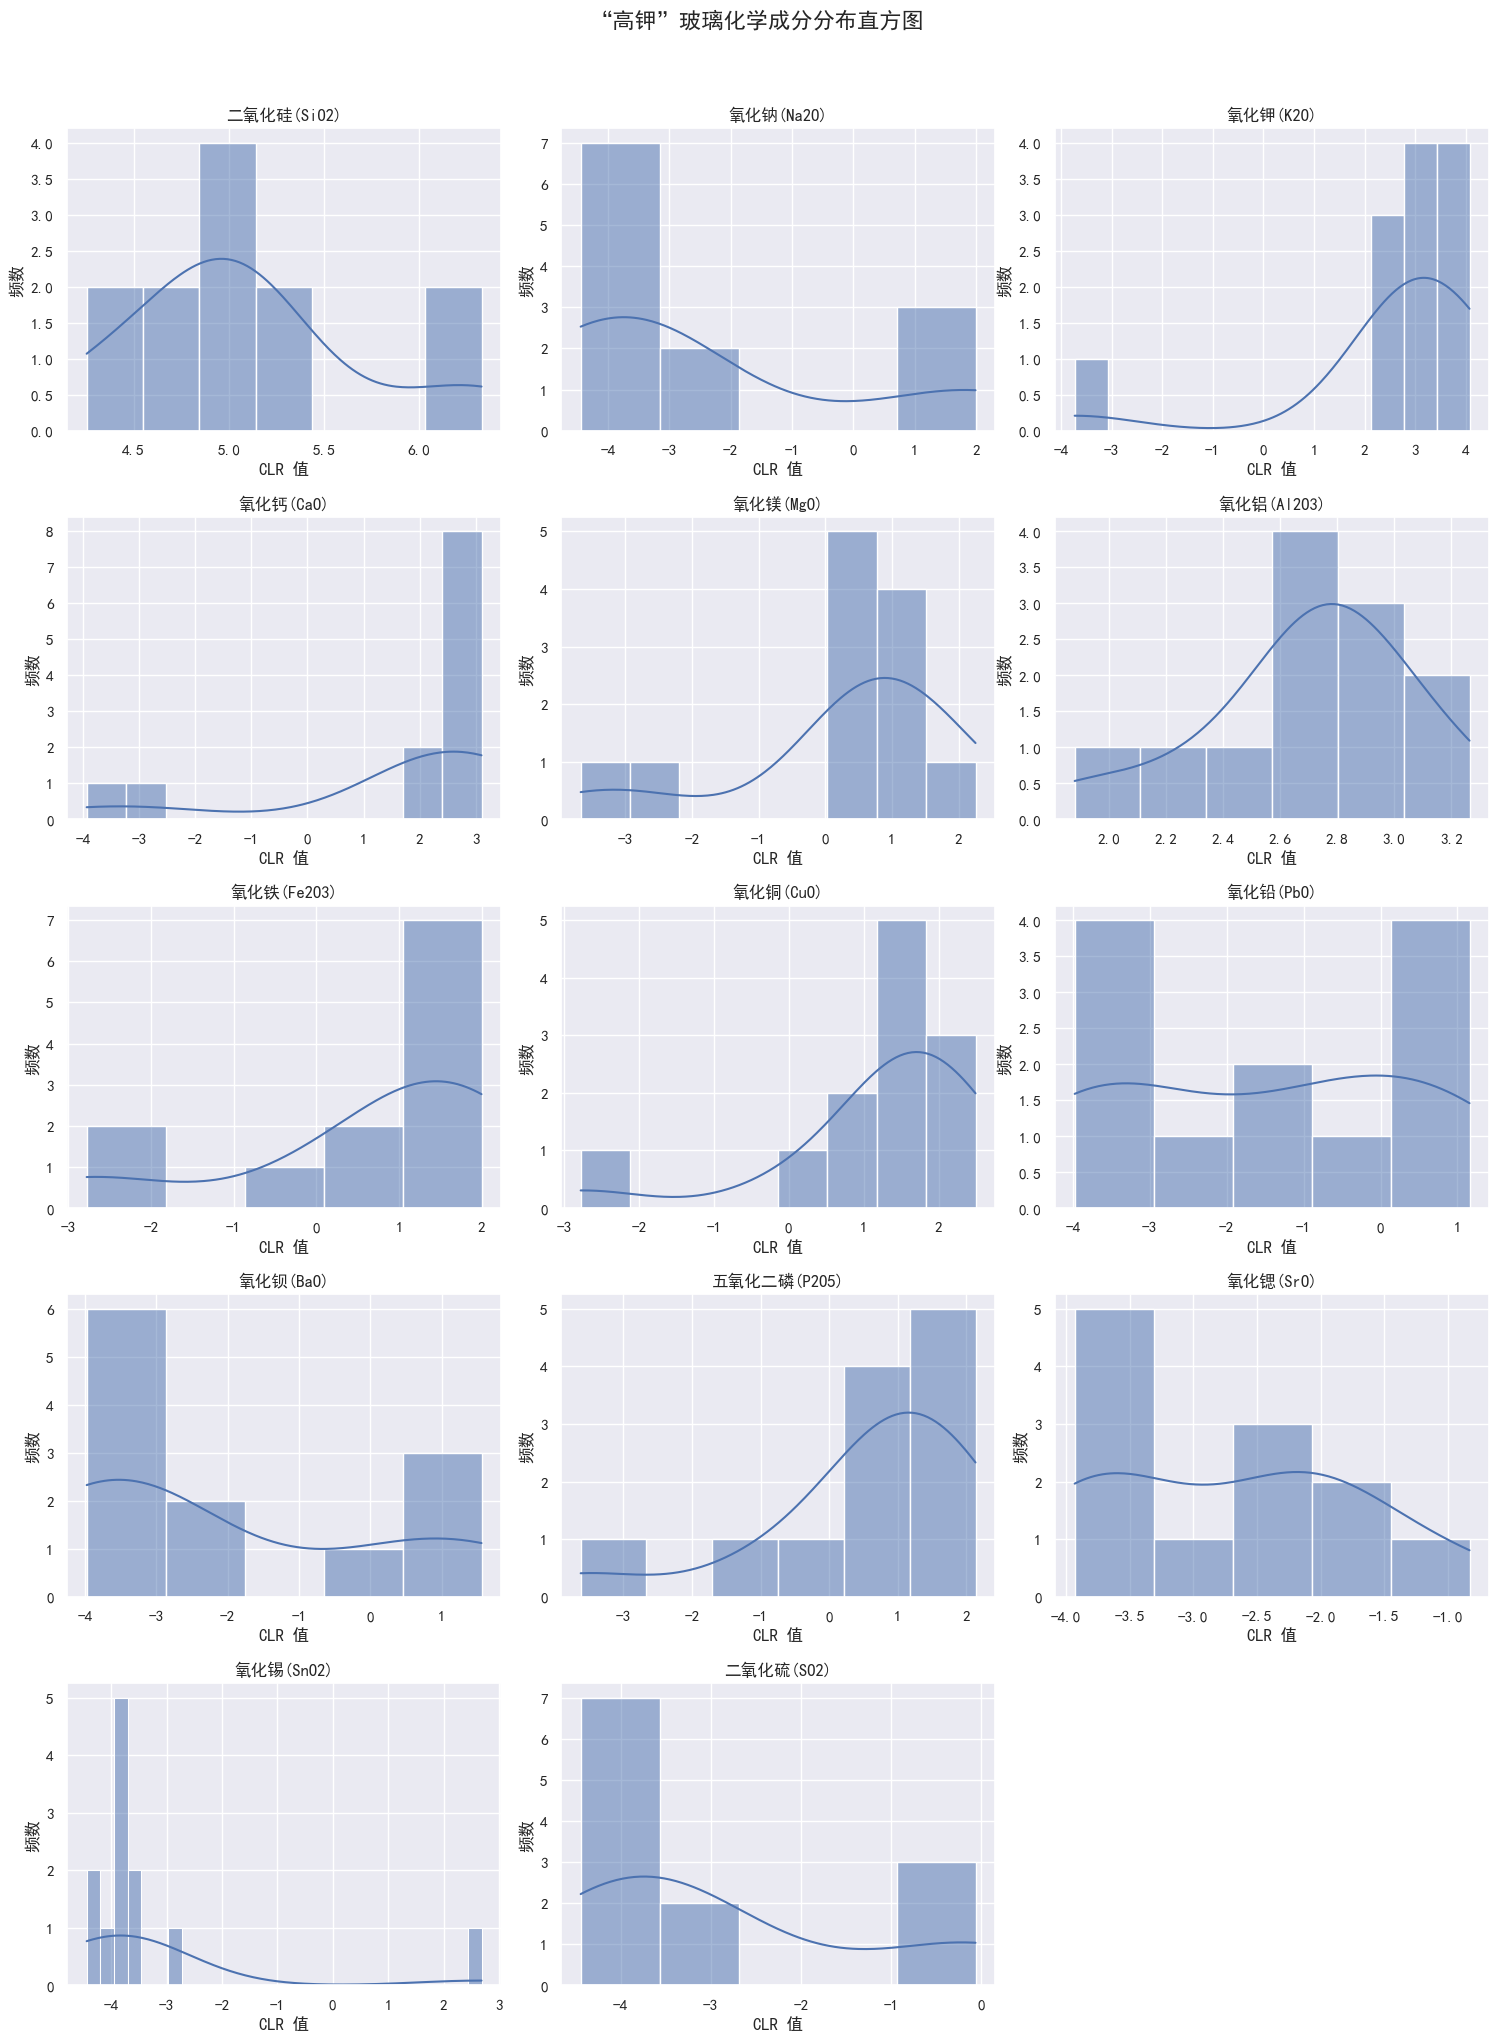


--- “铅钡”玻璃各化学成分分布 (CLR变换后) ---


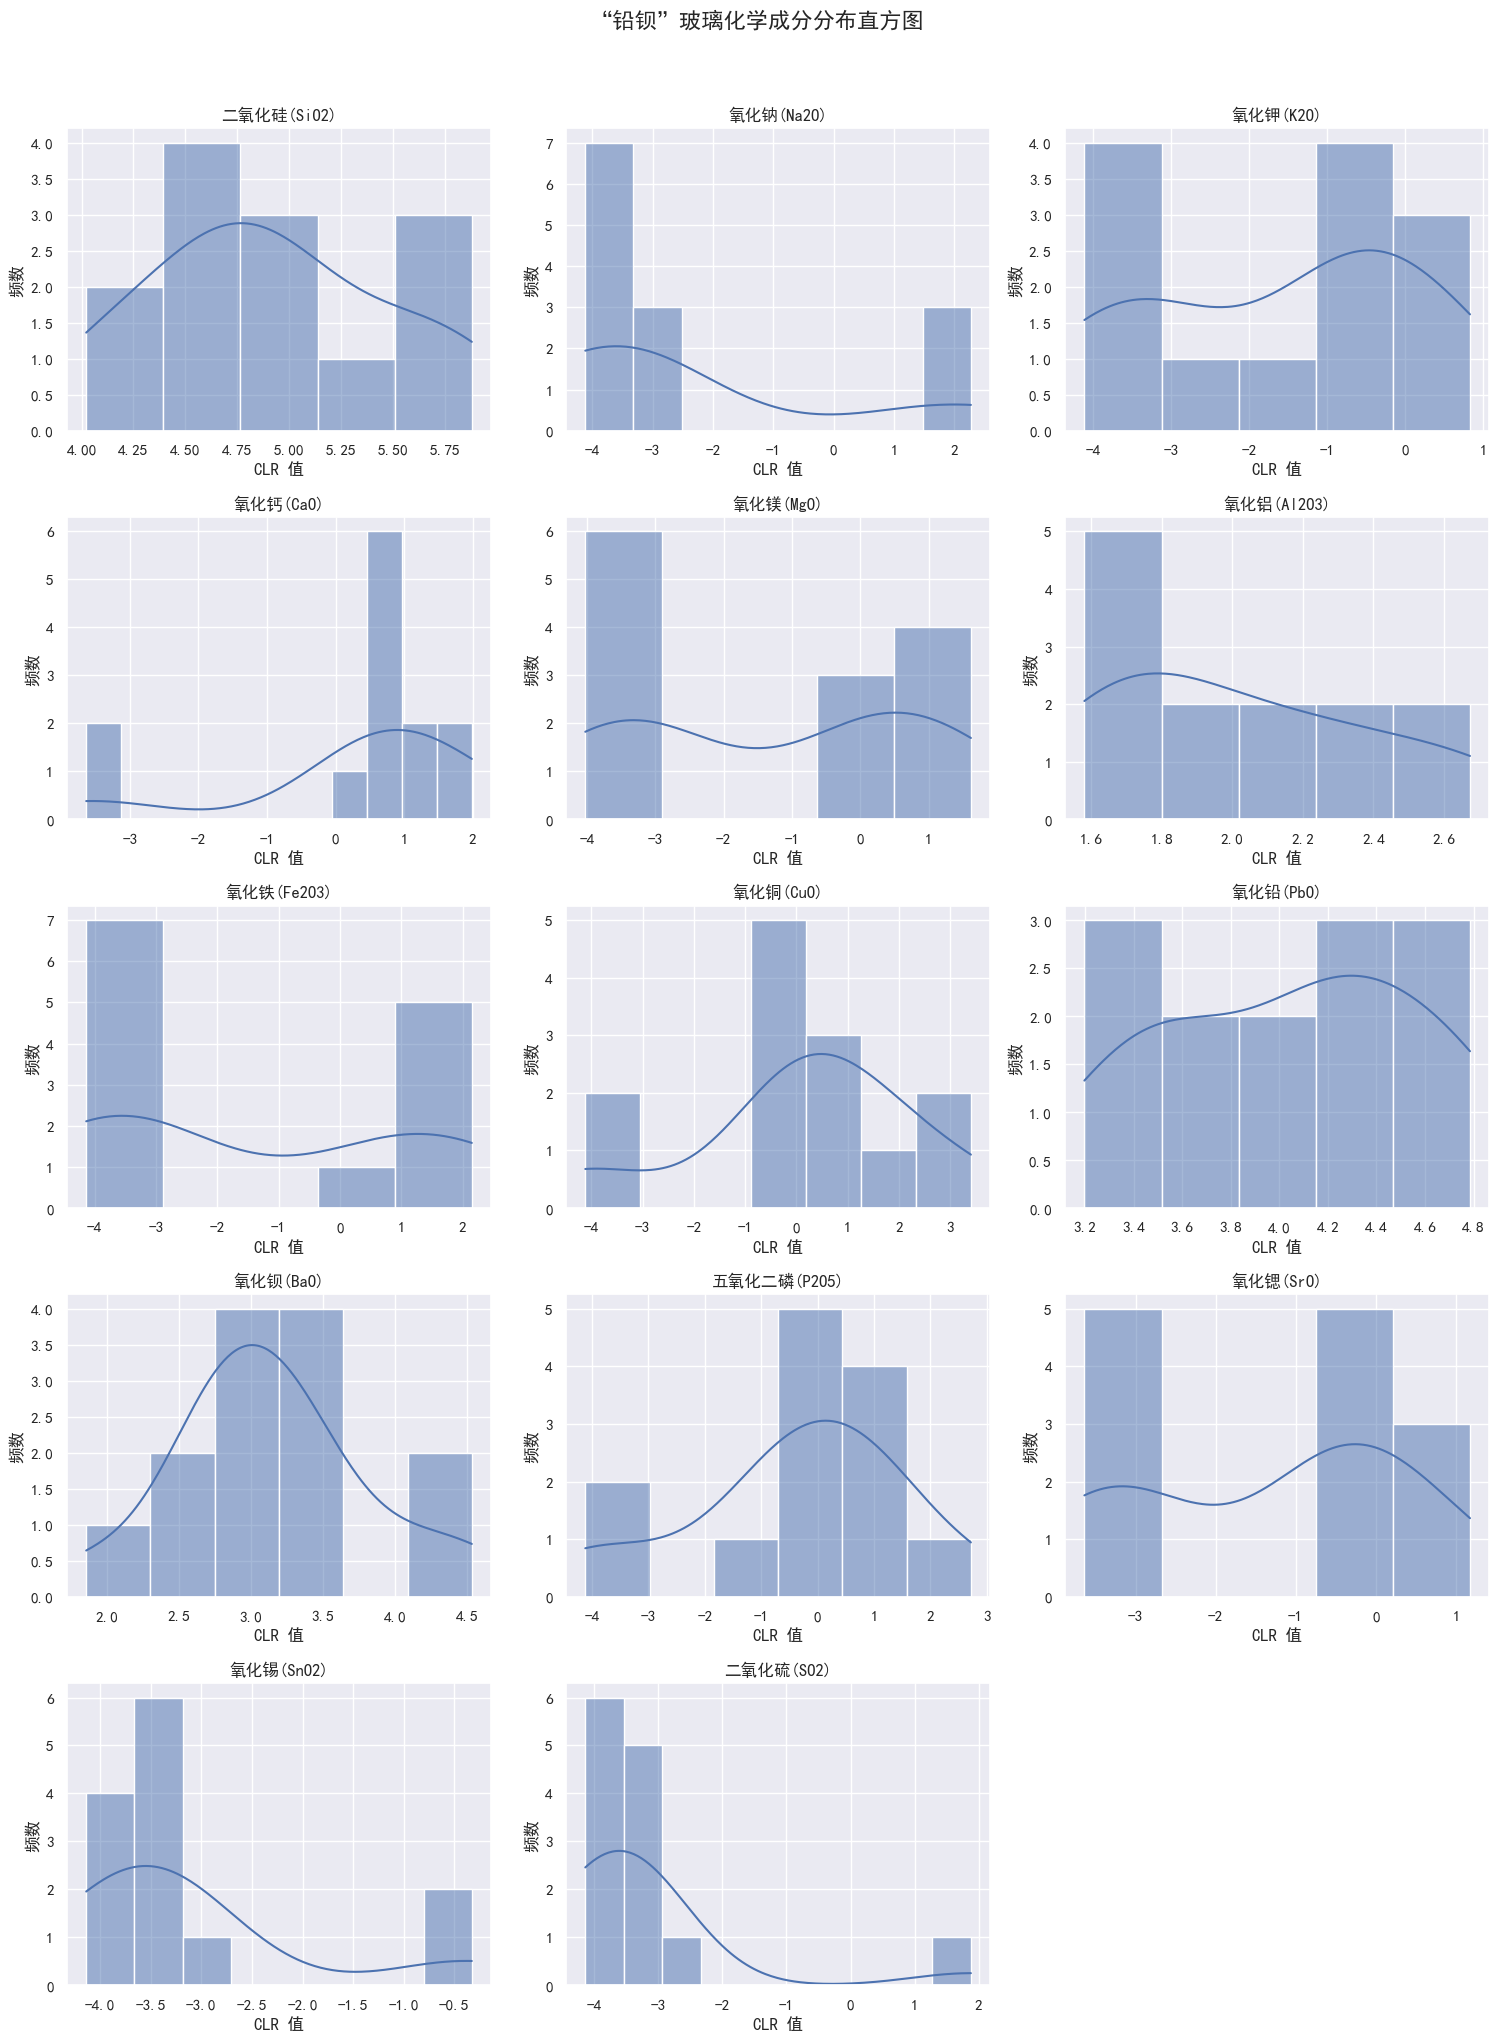


分析建议：
 - 观察上面两组图。如果某个化学成分的直方图出现多个明显的峰（例如，双峰或三峰），
   这强烈暗示该成分内部可能存在不同的亚类。
 - 分布特别宽泛（即使是单峰）的成分也值得关注，因为它可能包含了未被区分的群体。
 - 这些具有多模态或宽泛分布的成分是进行亚类划分的有力候选特征。


In [24]:

# 绘制两种类型玻璃的各成分分布直方图

# 筛选出无风化的样本数据，这与我们后续聚类分析使用的数据一致
unweathered_df = analysis_df[analysis_df['表面风化'] == '无风化'].copy()

# 获取所有化学成分的列名
chemical_features = features # 使用之前定义好的特征列

# 对每个类别进行绘图
for glass_type in ['高钾', '铅钡']:
    # 筛选出当前类别的数据
    df_type = unweathered_df[unweathered_df['类型'] == glass_type]
    
    if df_type.empty:
        print(f"未找到类型为“{glass_type}”的无风化样本，跳过绘图。")
        continue
        
    print(f"\n--- “{glass_type}”玻璃各化学成分分布 (CLR变换后) ---")
    
    # 计算子图的行数和列数
    n_cols = 3
    n_rows = (len(chemical_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    fig.suptitle(f'“{glass_type}”玻璃化学成分分布直方图', fontsize=16, y=1.02)
    
    # 将多维axes数组展平，方便遍历
    axes = axes.flatten()
    
    for i, component in enumerate(chemical_features):
        sns.histplot(df_type[component], kde=True, ax=axes[i])
        axes[i].set_title(component)
        axes[i].set_xlabel('CLR 值')
        axes[i].set_ylabel('频数')
        
    # 隐藏多余的子图
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

print("\n分析建议：")
print(" - 观察上面两组图。如果某个化学成分的直方图出现多个明显的峰（例如，双峰或三峰），")
print("   这强烈暗示该成分内部可能存在不同的亚类。")
print(" - 分布特别宽泛（即使是单峰）的成分也值得关注，因为它可能包含了未被区分的群体。")
print(" - 这些具有多模态或宽泛分布的成分是进行亚类划分的有力候选特征。")


In [25]:
# 处理：将风化点预测未风化之前的化学成分表
df_预测 = pd.read_excel('预测覆盖.xlsx', sheet_name = '表单2 (4)')  
df_预测.head()

,文物采样点,文物编号,类型,表面风化,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,01,1,高钾,无风化,69.33,0.04,9.99,6.32,0.87,3.93,1.74,3.87,0.04,0.04,1.17,0.04,0.04,0.39
1,03部位1,3,高钾,无风化,87.05,0.04,5.19,2.01,0.04,4.06,0.04,0.78,0.25,0.04,0.66,0.04,0.04,0.04
2,03部位2,3,高钾,无风化,61.71,0.04,12.37,5.87,1.11,5.50,2.16,5.09,1.41,2.86,0.70,0.10,0.04,0.04
3,04,4,高钾,无风化,65.88,0.04,9.67,7.12,1.56,6.44,2.06,2.18,0.04,0.04,0.79,0.04,0.04,0.36
4,05,5,高钾,无风化,61.58,0.04,10.95,7.35,1.77,7.50,2.62,3.27,0.04,0.04,0.94,0.06,0.04,0.47


In [26]:
# 问题二主分类

In [27]:
# 1. 数据准备 - 使用df_预测数据进行分析
# ================================================

# 首先对df_预测数据进行CLR变换
print("预测数据基本信息：")
print(f"数据形状: {df_预测.shape}")
print(f"列名: {list(df_预测.columns)}")
print(f"\n前5行数据:")
display(df_预测.head())

# 确定成分列（排除标识列）
composition_cols_pred = [col for col in df_预测.columns if col not in ['文物采样点', '成分比例累加和', '文物编号', '类型', '表面风化']]
print(f"\n化学成分列: {composition_cols_pred}")

# 对df_预测进行CLR变换
composition_data_pred = df_预测[composition_cols_pred].copy()
composition_data_pred.replace(0, 1e-9, inplace=True)

# 应用CLR变换
df_预测_clr = clr_transform(composition_data_pred)
df_预测_clr['文物采样点'] = df_预测['文物采样点']

# 提取文物编号并合并类型信息
df_预测_clr['文物编号'] = df_预测['文物采样点'].astype(str).str.extract(r'^(\d+)').iloc[:, 0].astype(int)
analysis_df_pred = pd.merge(df_预测_clr, df1_info, on='文物编号', how='left')

print(f"\n合并后的预测数据:")
display(analysis_df_pred.head())


预测数据基本信息：
数据形状: (35, 18)
列名: ['文物采样点', '文物编号', '类型', '表面风化', '二氧化硅(SiO2)', '氧化钠(Na2O)', '氧化钾(K2O)', '氧化钙(CaO)', '氧化镁(MgO)', '氧化铝(Al2O3)', '氧化铁(Fe2O3)', '氧化铜(CuO)', '氧化铅(PbO)', '氧化钡(BaO)', '五氧化二磷(P2O5)', '氧化锶(SrO)', '氧化锡(SnO2)', '二氧化硫(SO2)']

前5行数据:


,文物采样点,文物编号,类型,表面风化,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,01,1,高钾,无风化,69.33,0.04,9.99,6.32,0.87,3.93,1.74,3.87,0.04,0.04,1.17,0.04,0.04,0.39
1,03部位1,3,高钾,无风化,87.05,0.04,5.19,2.01,0.04,4.06,0.04,0.78,0.25,0.04,0.66,0.04,0.04,0.04
2,03部位2,3,高钾,无风化,61.71,0.04,12.37,5.87,1.11,5.50,2.16,5.09,1.41,2.86,0.70,0.10,0.04,0.04
3,04,4,高钾,无风化,65.88,0.04,9.67,7.12,1.56,6.44,2.06,2.18,0.04,0.04,0.79,0.04,0.04,0.36
4,05,5,高钾,无风化,61.58,0.04,10.95,7.35,1.77,7.50,2.62,3.27,0.04,0.04,0.94,0.06,0.04,0.47



化学成分列: ['二氧化硅(SiO2)', '氧化钠(Na2O)', '氧化钾(K2O)', '氧化钙(CaO)', '氧化镁(MgO)', '氧化铝(Al2O3)', '氧化铁(Fe2O3)', '氧化铜(CuO)', '氧化铅(PbO)', '氧化钡(BaO)', '五氧化二磷(P2O5)', '氧化锶(SrO)', '氧化锡(SnO2)', '二氧化硫(SO2)']

合并后的预测数据:


,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2),文物采样点,文物编号,类型,表面风化
0,4.621612,-2.836141,2.684319,2.226454,0.243473,1.751374,0.936620,1.735989,-2.836141,-2.836141,0.539738,-2.836141,-2.836141,-0.558874,01,1,高钾,无风化
1,5.635759,-2.049600,2.816010,1.867411,-2.049600,2.570459,-2.049600,0.920815,-0.217018,-2.049600,0.753761,-2.049600,-2.049600,-2.049600,03部位1,3,高钾,无风化
2,4.001547,-3.339775,2.394375,1.648955,-0.016539,1.583849,0.649209,1.506378,0.222690,0.929922,-0.477574,-2.423485,-3.339775,-3.339775,03部位2,3,高钾,无风化
3,4.553745,-2.852966,2.634938,2.328817,0.810596,2.228438,1.088616,1.145235,-2.852966,-2.852966,0.130187,-2.852966,-2.852966,-0.655741,04,4,高钾,无风化
4,4.353451,-2.985762,2.626453,2.227814,0.804093,2.248016,1.196288,1.417903,-2.985762,-2.985762,0.171238,-2.580297,-2.985762,-0.521909,05,5,高钾,无风化


In [28]:
# 2. 筛选关键成分和目标类别
# ================================================

# 筛选出高钾玻璃和铅钡玻璃的样本
classification_df = analysis_df_pred[
    analysis_df_pred['类型'].isin(['高钾', '铅钡'])
].copy()

print(f"用于分类的样本数量: {len(classification_df)}")
print("\n各类样本分布:")
print(classification_df['类型'].value_counts())

# 重点分析二氧化硅(SiO2), 氧化铅(PbO), 氧化钡(BaO)三个关键成分
key_components = ['二氧化硅(SiO2)', '氧化铅(PbO)', '氧化钡(BaO)']
print(f"\n关键分类成分: {key_components}")

# 检查这些成分是否都存在于数据中
missing_components = [comp for comp in key_components if comp not in classification_df.columns]
if missing_components:
    print(f"警告: 以下成分在数据中缺失: {missing_components}")
else:
    print("✓ 所有关键成分都存在于数据中")

# 准备建模数据
X_key = classification_df[key_components]
y_class = classification_df['类型']

# 编码目标变量
le_class = LabelEncoder()
y_encoded_class = le_class.fit_transform(y_class)

print(f"\n目标变量编码:")
for i, class_name in enumerate(le_class.classes_):
    print(f"  {class_name} -> {i}")

print(f"\n关键成分数据形状: {X_key.shape}")
print(f"目标变量形状: {y_encoded_class.shape}")

# 显示关键成分的统计信息
print(f"\n关键成分统计信息 (CLR变换后):")
display(X_key.describe())

用于分类的样本数量: 35

各类样本分布:
类型
铅钡    23
高钾    12
Name: count, dtype: int64

关键分类成分: ['二氧化硅(SiO2)', '氧化铅(PbO)', '氧化钡(BaO)']
✓ 所有关键成分都存在于数据中

目标变量编码:
  铅钡 -> 0
  高钾 -> 1

关键成分数据形状: (35, 3)
目标变量形状: (35,)

关键成分统计信息 (CLR变换后):


,二氧化硅(SiO2),氧化铅(PbO),氧化钡(BaO)
count,35.000000,35.000000,35.000000
mean,4.487438,1.805770,0.582590
std,0.530737,2.434069,3.993852
min,3.626176,-2.985762,-18.885320
25%,4.124312,0.002836,0.215226
50%,4.413155,3.033653,2.124438
75%,4.598386,3.684671,2.545454
max,6.015099,4.191147,3.940243


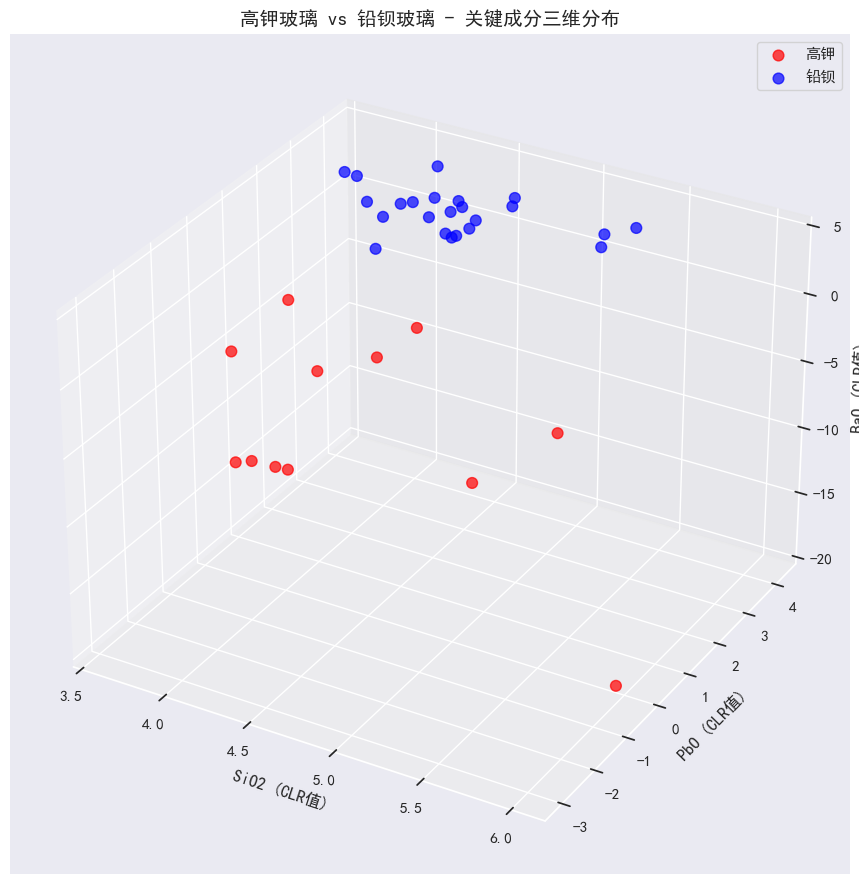

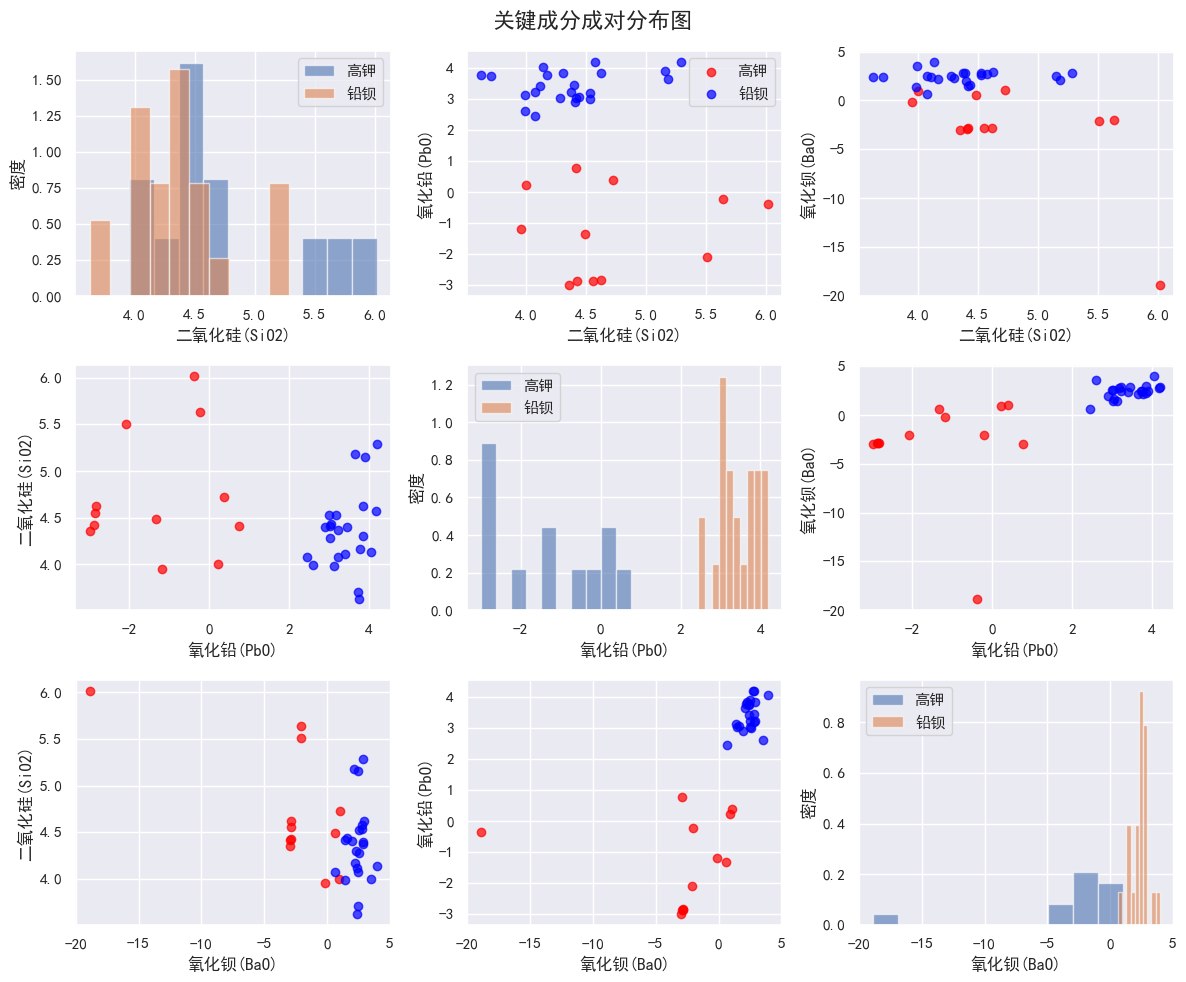

In [29]:
# 3. 三维可视化关键成分分布
# ================================================

# 创建三维散点图展示SiO2, PbO, BaO的分布
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 为不同类型设置不同颜色
colors = {'高钾': 'red', '铅钡': 'blue'}
for glass_type in ['高钾', '铅钡']:
    type_data = classification_df[classification_df['类型'] == glass_type]
    ax.scatter(type_data['二氧化硅(SiO2)'], type_data['氧化铅(PbO)'], type_data['氧化钡(BaO)'], 
              c=colors[glass_type], label=glass_type, s=60, alpha=0.7)

ax.set_xlabel('SiO2 (CLR值)')
ax.set_ylabel('PbO (CLR值)')
ax.set_zlabel('BaO (CLR值)')
ax.set_title('高钾玻璃 vs 铅钡玻璃 - 关键成分三维分布', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

# 绘制成对散点图矩阵
plt.figure(figsize=(12, 10))
for i, comp1 in enumerate(key_components):
    for j, comp2 in enumerate(key_components):
        plt.subplot(3, 3, i*3 + j + 1)
        
        if i == j:
            # 对角线绘制密度图
            for glass_type in ['高钾', '铅钡']:
                type_data = classification_df[classification_df['类型'] == glass_type]
                plt.hist(type_data[comp1], alpha=0.6, label=glass_type, density=True)
            plt.xlabel(comp1)
            plt.ylabel('密度')
            plt.legend()
        else:
            # 非对角线绘制散点图
            for glass_type in ['高钾', '铅钡']:
                type_data = classification_df[classification_df['类型'] == glass_type]
                plt.scatter(type_data[comp1], type_data[comp2], 
                           c=colors[glass_type], label=glass_type, alpha=0.7)
            plt.xlabel(comp1)
            plt.ylabel(comp2)
            if i == 0 and j == 1:  # 只在第一个子图显示图例
                plt.legend()

plt.suptitle('关键成分成对分布图', fontsize=16)
plt.tight_layout()
plt.show()

训练集大小: 24
测试集大小: 11

SVM线性分类器准确率: 1.0000
5折交叉验证平均准确率: 1.0000 ± 0.0000

详细分类报告:
              precision    recall  f1-score   support

          铅钡       1.00      1.00      1.00         7
          高钾       1.00      1.00      1.00         4

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



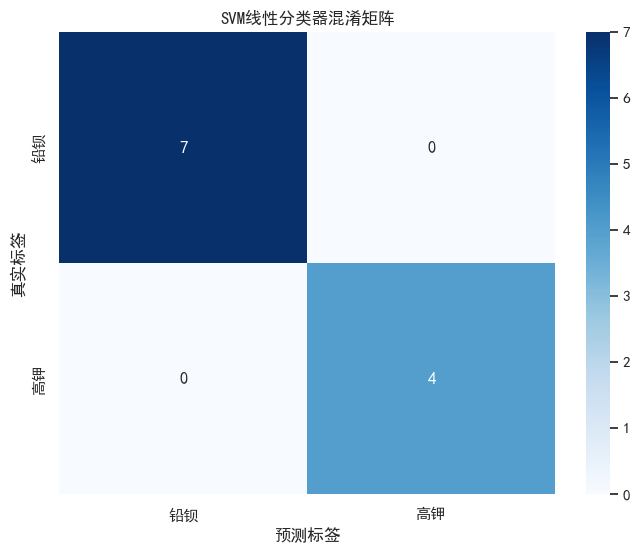

In [30]:
# 4. SVM线性分类器训练
# ================================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 数据标准化（对SVM很重要）
scaler = StandardScaler()
X_key_scaled = scaler.fit_transform(X_key)

# 分割训练集和测试集
X_train_key, X_test_key, y_train_key, y_test_key = train_test_split(
    X_key_scaled, y_encoded_class, test_size=0.3, random_state=42, stratify=y_encoded_class
)

print(f"训练集大小: {X_train_key.shape[0]}")
print(f"测试集大小: {X_test_key.shape[0]}")

# 训练SVM线性分类器
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_key, y_train_key)

# 预测
y_pred_key = svm_linear.predict(X_test_key)

# 模型性能评估
accuracy_key = accuracy_score(y_test_key, y_pred_key)
print(f"\nSVM线性分类器准确率: {accuracy_key:.4f}")

# 交叉验证评估
cv_scores = cross_val_score(svm_linear, X_key_scaled, y_encoded_class, cv=5)
print(f"5折交叉验证平均准确率: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print(f"\n详细分类报告:")
print(classification_report(y_test_key, y_pred_key, target_names=le_class.classes_))

# 混淆矩阵
cm_key = confusion_matrix(y_test_key, y_pred_key)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_key, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_class.classes_, yticklabels=le_class.classes_)
plt.title('SVM线性分类器混淆矩阵')
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.show()

SVM线性分类器最优分割平面参数:
权重向量 w = [0.130254, -1.181923, -0.122726]
截距 b = -0.364742

分割平面方程（标准化特征空间）:
0.130254 × SiO2_scaled + -1.181923 × PbO_scaled + -0.122726 × BaO_scaled + -0.364742 = 0

支持向量数量: 5
支持向量索引: [ 8 14  2  6 11]

分类间隔（margin）: 0.836543

特征重要性排序:


,化学成分,权重,重要性(绝对值)
1,氧化铅(PbO),-1.181923,1.181923
0,二氧化硅(SiO2),0.130254,0.130254
2,氧化钡(BaO),-0.122726,0.122726


D:\TEMP\USER_TEMP\ipykernel_28648\1543193017.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='权重', y='化学成分', data=feature_importance_key, palette='RdBu_r')


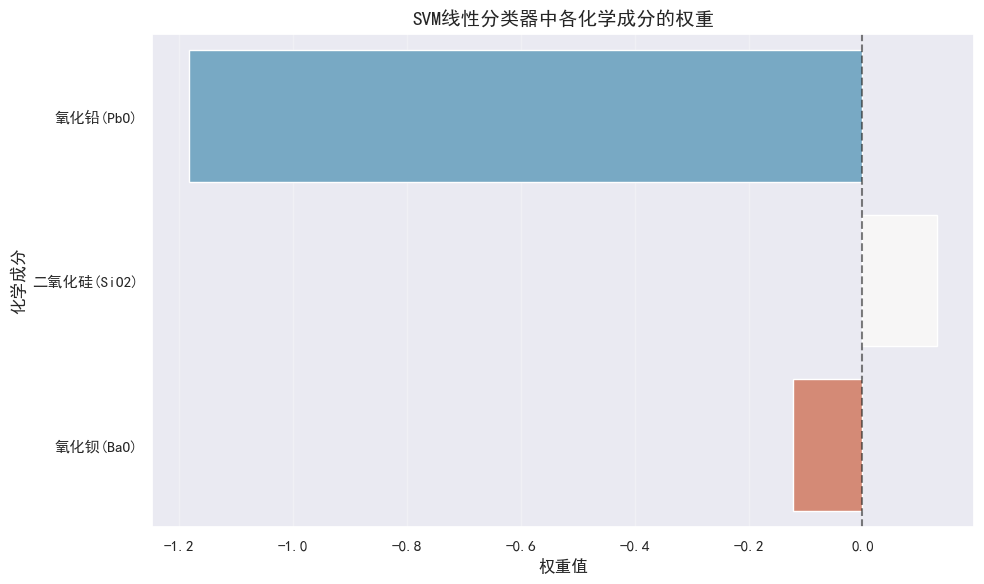


权重解释:
• 正权重: 该成分含量越高，越倾向于分类为 '高钾'
• 负权重: 该成分含量越高，越倾向于分类为 '铅钡'
• 权重绝对值越大，该成分对分类的影响越大


In [31]:
# 5. 计算和可视化SVM最优分割平面
# ================================================

# 获取SVM分类器的参数
w = svm_linear.coef_[0]  # 法向量（权重向量）
b = svm_linear.intercept_[0]  # 截距

print("="*60)
print("SVM线性分类器最优分割平面参数:")
print("="*60)
print(f"权重向量 w = [{w[0]:.6f}, {w[1]:.6f}, {w[2]:.6f}]")
print(f"截距 b = {b:.6f}")

# 分割平面方程: w0*x0 + w1*x1 + w2*x2 + b = 0
# 即: {w[0]:.6f}*SiO2 + {w[1]:.6f}*PbO + {w[2]:.6f}*BaO + {b:.6f} = 0
print(f"\n分割平面方程（标准化特征空间）:")
print(f"{w[0]:.6f} × SiO2_scaled + {w[1]:.6f} × PbO_scaled + {w[2]:.6f} × BaO_scaled + {b:.6f} = 0")

# 计算支持向量
support_vectors = svm_linear.support_vectors_
support_vector_indices = svm_linear.support_
print(f"\n支持向量数量: {len(support_vectors)}")
print(f"支持向量索引: {support_vector_indices}")

# 计算到分割平面的距离（margin）
distances = np.abs(np.dot(X_key_scaled, w) + b) / np.linalg.norm(w)
margin = 1.0 / np.linalg.norm(w)
print(f"\n分类间隔（margin）: {margin:.6f}")

# 特征重要性分析
feature_importance_key = pd.DataFrame({
    '化学成分': key_components,
    '权重': w,
    '重要性(绝对值)': np.abs(w)
}).sort_values('重要性(绝对值)', ascending=False)

print(f"\n特征重要性排序:")
display(feature_importance_key)

# 可视化特征权重
plt.figure(figsize=(10, 6))
sns.barplot(x='权重', y='化学成分', data=feature_importance_key, palette='RdBu_r')
plt.title('SVM线性分类器中各化学成分的权重', fontsize=14)
plt.xlabel('权重值')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n权重解释:")
print(f"• 正权重: 该成分含量越高，越倾向于分类为 '{le_class.classes_[1]}'")
print(f"• 负权重: 该成分含量越高，越倾向于分类为 '{le_class.classes_[0]}'")
print(f"• 权重绝对值越大，该成分对分类的影响越大")

标准化参数:
二氧化硅(SiO2): 均值=4.487438, 标准差=0.523100
氧化铅(PbO): 均值=1.805770, 标准差=2.399045
氧化钡(BaO): 均值=0.582590, 标准差=3.936384

原始特征空间的分割平面参数:
权重向量 w_original = [0.249004, -0.492664, -0.031177]
截距 b_original = -0.574333

原始特征空间的分割平面方程（CLR变换后的特征）:
0.249004 × 二氧化硅(SiO2) + -0.492664 × 氧化铅(PbO) + -0.031177 × 氧化钡(BaO) + -0.574333 = 0

简化的分类决策函数:
f(二氧化硅(SiO2), 氧化铅(PbO), 氧化钡(BaO)) = 0.249×二氧化硅(SiO2) + -0.493×氧化铅(PbO) + -0.031×氧化钡(BaO) + -0.574
分类规则:
• f(x) > 0 → 高钾
• f(x) < 0 → 铅钡

验证：使用原始空间方程的分类准确率: 1.0000

验证：使用原始空间方程的分类准确率: 1.0000


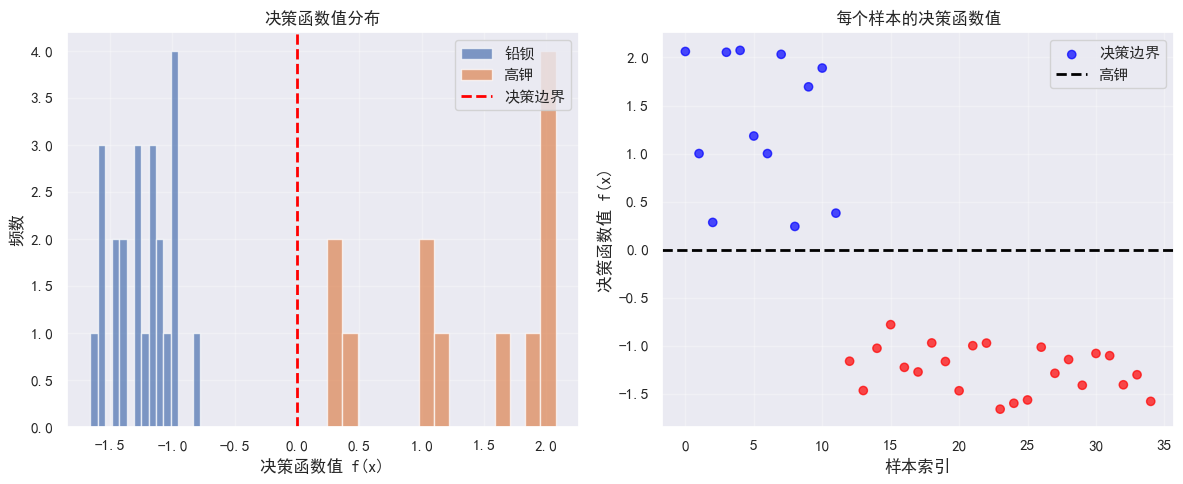

In [32]:
# 6. 转换到原始特征空间的分割平面方程
# ================================================

# 由于我们对特征进行了标准化，需要将分割平面方程转换回原始特征空间
# 标准化转换: x_scaled = (x - mean) / std
# 逆转换: x = x_scaled * std + mean

# 获取标准化参数
feature_means = scaler.mean_
feature_stds = scaler.scale_

print("标准化参数:")
for i, comp in enumerate(key_components):
    print(f"{comp}: 均值={feature_means[i]:.6f}, 标准差={feature_stds[i]:.6f}")

# 计算原始特征空间的权重和截距
# 原始空间的权重: w_original = w_scaled / std
w_original = w / feature_stds

# 原始空间的截距: b_original = b_scaled - sum(w_scaled * mean / std)
b_original = b - np.sum(w * feature_means / feature_stds)

print(f"\n原始特征空间的分割平面参数:")
print(f"权重向量 w_original = [{w_original[0]:.6f}, {w_original[1]:.6f}, {w_original[2]:.6f}]")
print(f"截距 b_original = {b_original:.6f}")

print(f"\n原始特征空间的分割平面方程（CLR变换后的特征）:")
print(f"{w_original[0]:.6f} × 二氧化硅(SiO2) + {w_original[1]:.6f} × 氧化铅(PbO) + {w_original[2]:.6f} × 氧化钡(BaO) + {b_original:.6f} = 0")

# 简化表示
print(f"\n简化的分类决策函数:")
print(f"f(二氧化硅(SiO2), 氧化铅(PbO), 氧化钡(BaO)) = {w_original[0]:.3f}×二氧化硅(SiO2) + {w_original[1]:.3f}×氧化铅(PbO) + {w_original[2]:.3f}×氧化钡(BaO) + {b_original:.3f}")
print(f"分类规则:")
print(f"• f(x) > 0 → {le_class.classes_[1]}")
print(f"• f(x) < 0 → {le_class.classes_[0]}")

# 验证分类准确性
X_original = X_key.values
decision_values = np.dot(X_original, w_original) + b_original
predicted_labels = (decision_values > 0).astype(int)
accuracy_check = accuracy_score(y_encoded_class, predicted_labels)
print(f"\n验证：使用原始空间方程的分类准确率: {accuracy_check:.4f}")

# 创建决策值分布图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, glass_type in enumerate(le_class.classes_):
    mask = y_encoded_class == i
    plt.hist(decision_values[mask], alpha=0.7, label=glass_type, bins=15)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='决策边界')
plt.xlabel('决策函数值 f(x)')
plt.ylabel('频数')
plt.title('决策函数值分布')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
colors = ['red' if y == 0 else 'blue' for y in y_encoded_class]
plt.scatter(range(len(decision_values)), decision_values, c=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='决策边界')
plt.xlabel('样本索引')
plt.ylabel('决策函数值 f(x)')
plt.title('每个样本的决策函数值')
plt.legend(['决策边界', '高钾', '铅钡'])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

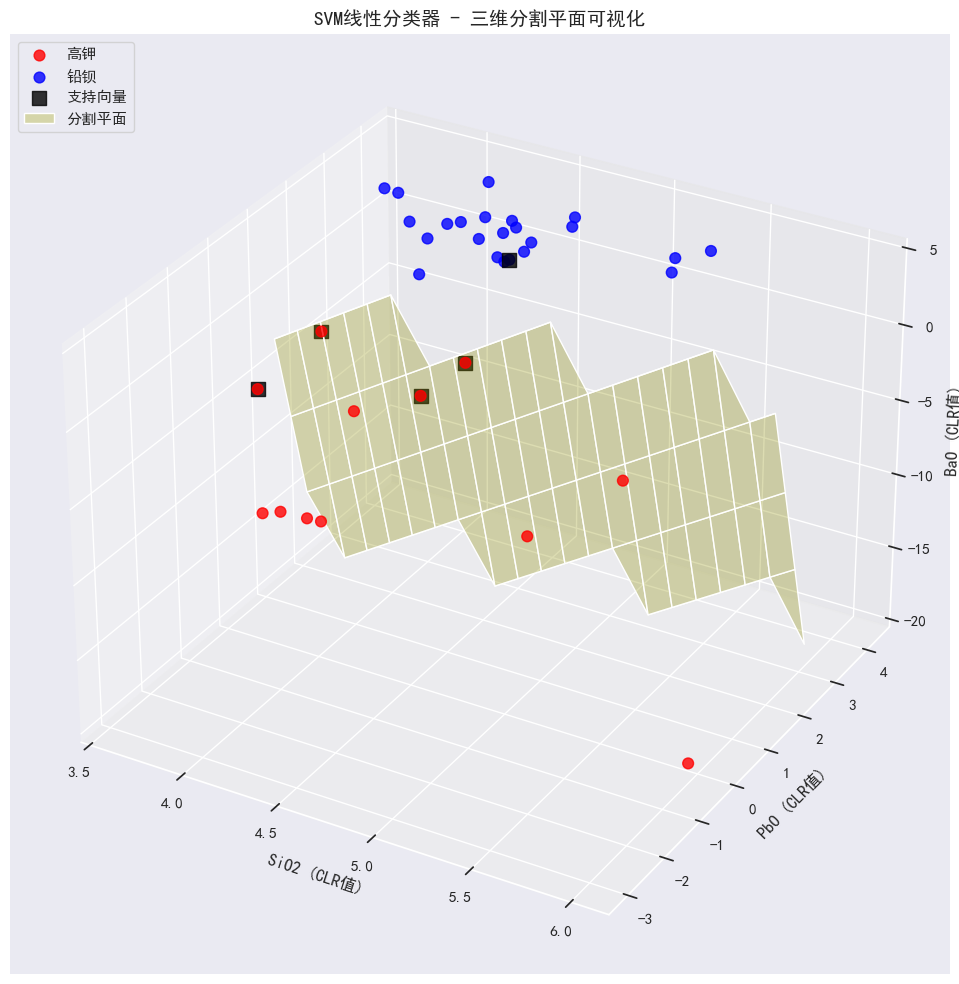

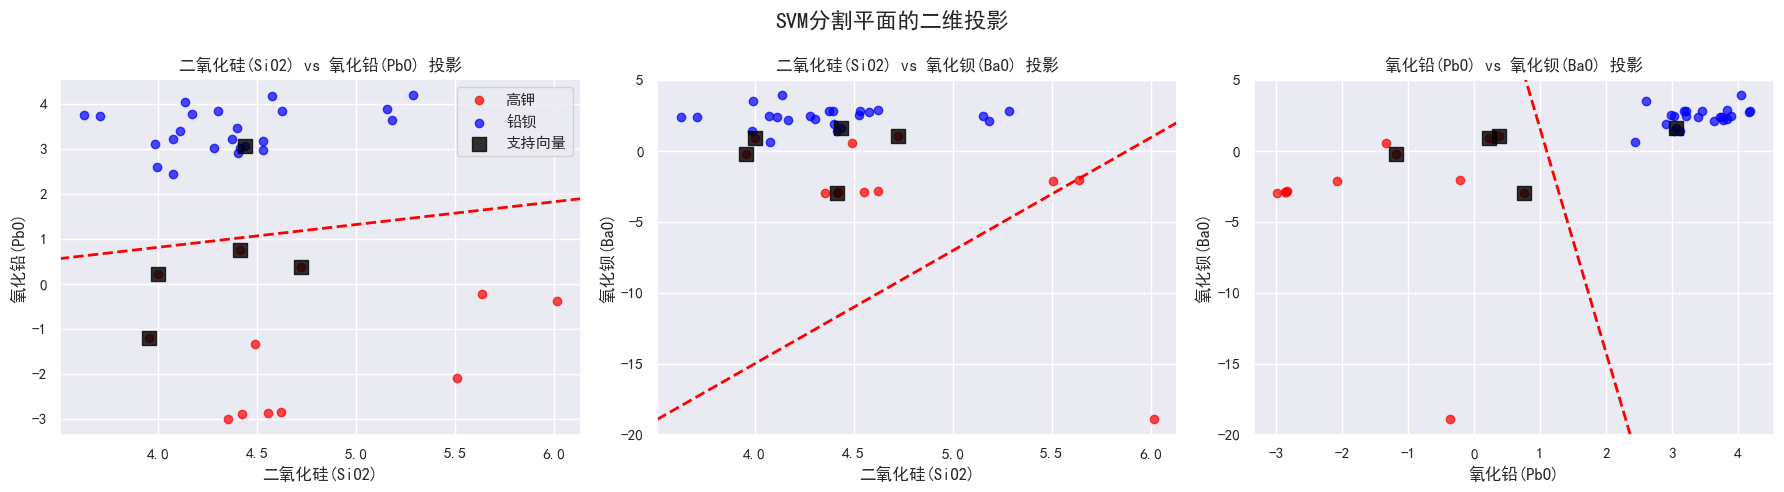

In [33]:
# 7. 三维空间分割平面可视化
# ================================================

# 创建三维图形显示分割平面
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制数据点
colors = {'高钾': 'red', '铅钡': 'blue'}
for glass_type in ['高钾', '铅钡']:
    type_data = classification_df[classification_df['类型'] == glass_type]
    ax.scatter(type_data['二氧化硅(SiO2)'], type_data['氧化铅(PbO)'], type_data['氧化钡(BaO)'], 
              c=colors[glass_type], label=glass_type, s=60, alpha=0.8)

# 绘制支持向量（加大尺寸显示）
support_indices_in_original = classification_df.index[support_vector_indices]
support_data = classification_df.loc[support_indices_in_original]
ax.scatter(support_data['二氧化硅(SiO2)'], support_data['氧化铅(PbO)'], support_data['氧化钡(BaO)'], 
          c='black', s=100, marker='s', label='支持向量', alpha=0.8)

# 创建分割平面
# 分割平面方程: w_original[0]*x + w_original[1]*y + w_original[2]*z + b_original = 0
# 解出 z = -(w_original[0]*x + w_original[1]*y + b_original) / w_original[2]

# 创建网格
x_range = np.linspace(classification_df['二氧化硅(SiO2)'].min(), classification_df['二氧化硅(SiO2)'].max(), 20)
y_range = np.linspace(classification_df['氧化铅(PbO)'].min(), classification_df['氧化铅(PbO)'].max(), 20)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# 计算对应的z值（BaO）
if abs(w_original[2]) > 1e-6:  # 避免除零
    Z_mesh = -(w_original[0] * X_mesh + w_original[1] * Y_mesh + b_original) / w_original[2]
    
    # 只显示在数据范围内的平面部分
    z_min, z_max = classification_df['氧化钡(BaO)'].min(), classification_df['氧化钡(BaO)'].max()
    Z_mesh = np.where((Z_mesh >= z_min) & (Z_mesh <= z_max), Z_mesh, np.nan)
    
    # 绘制分割平面
    ax.plot_surface(X_mesh, Y_mesh, Z_mesh, alpha=0.3, color='yellow', label='分割平面')

ax.set_xlabel('SiO2 (CLR值)')
ax.set_ylabel('PbO (CLR值)')
ax.set_zlabel('BaO (CLR值)')
ax.set_title('SVM线性分类器 - 三维分割平面可视化', fontsize=14)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# 绘制二维投影图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

projections = [
    ('二氧化硅(SiO2)', '氧化铅(PbO)', 0, 1),
    ('二氧化硅(SiO2)', '氧化钡(BaO)', 0, 2),
    ('氧化铅(PbO)', '氧化钡(BaO)', 1, 2)
]

for idx, (x_name, y_name, x_idx, y_idx) in enumerate(projections):
    ax = axes[idx]
    
    # 绘制数据点
    for glass_type in ['高钾', '铅钡']:
        type_data = classification_df[classification_df['类型'] == glass_type]
        ax.scatter(type_data[x_name], type_data[y_name], 
                  c=colors[glass_type], label=glass_type, alpha=0.7)
    
    # 绘制支持向量
    ax.scatter(support_data[x_name], support_data[y_name], 
              c='black', s=100, marker='s', label='支持向量', alpha=0.8)
    
    # 绘制决策边界（二维投影）
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # 创建网格点
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                        np.linspace(ylim[0], ylim[1], 100))
    
    # 对于二维投影，我们需要固定第三个维度
    # 这里使用该维度的均值
    if idx == 0:  # 二氧化硅(SiO2) vs 氧化铅(PbO)，固定氧化钡(BaO)
        zz = np.full_like(xx, classification_df['氧化钡(BaO)'].mean())
        mesh_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
    elif idx == 1:  # 二氧化硅(SiO2) vs 氧化钡(BaO)，固定氧化铅(PbO)
        zz = np.full_like(xx, classification_df['氧化铅(PbO)'].mean())
        mesh_points = np.c_[xx.ravel(), zz.ravel(), yy.ravel()]
    else:  # 氧化铅(PbO) vs 氧化钡(BaO)，固定二氧化硅(SiO2)
        zz = np.full_like(xx, classification_df['二氧化硅(SiO2)'].mean())
        mesh_points = np.c_[zz.ravel(), xx.ravel(), yy.ravel()]
    
    # 计算决策值
    decision_mesh = np.dot(mesh_points, w_original) + b_original
    decision_mesh = decision_mesh.reshape(xx.shape)
    
    # 绘制决策边界
    ax.contour(xx, yy, decision_mesh, levels=[0], colors='red', linestyles='--', linewidths=2)
    
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(f'{x_name} vs {y_name} 投影')
    if idx == 0:
        ax.legend()

plt.suptitle('SVM分割平面的二维投影', fontsize=16)
plt.tight_layout()
plt.show()

In [34]:
# 8. 核函数计算和分类规律总结
# ================================================

print("="*80)
print("                    SVM线性核函数分析结果总结")
print("="*80)

# 核函数计算
print("\n1. 核函数计算:")
print("   线性核函数: K(xi, xj) = xi · xj")
print("   对于线性SVM，核函数就是向量内积")

# 示例计算几个核函数值
sample_indices = [0, 1, len(X_key_scaled)//2]
print(f"\n   示例核函数值计算:")
for i in sample_indices[:2]:
    for j in sample_indices[:2]:
        if i <= j:
            kernel_value = np.dot(X_key_scaled[i], X_key_scaled[j])
            print(f"   K(样本{i+1}, 样本{j+1}) = {kernel_value:.6f}")

print(f"\n2. 最优分割平面参数:")
print(f"   权重向量 w = [{w_original[0]:.4f}, {w_original[1]:.4f}, {w_original[2]:.4f}]")
print(f"   截距 b = {b_original:.4f}")
print(f"   分类间隔 margin = {margin:.6f}")

print(f"\n3. 分割平面方程（CLR变换后的特征空间）:")
print(f"   {w_original[0]:.4f} × 二氧化硅(SiO2) + {w_original[1]:.4f} × 氧化铅(PbO) + {w_original[2]:.4f} × 氧化钡(BaO) + {b_original:.4f} = 0")

print(f"\n4. 分类规律分析:")
for i, comp in enumerate(key_components):
    weight = w_original[i]
    if weight > 0:
        tendency = f"促进分类为'{le_class.classes_[1]}'"
    else:
        tendency = f"促进分类为'{le_class.classes_[0]}'"
    print(f"   • {comp}: 权重={weight:.4f}, {tendency}")

print(f"\n5. 模型性能:")
print(f"   训练准确率: {svm_linear.score(X_train_key, y_train_key):.4f}")
print(f"   测试准确率: {accuracy_key:.4f}")
print(f"   交叉验证准确率: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   支持向量数量: {len(support_vectors)}")

print(f"\n6. 关键发现:")
# 分析哪个成分最重要
most_important_idx = np.argmax(np.abs(w_original))
most_important_comp = key_components[most_important_idx]
print(f"   • 最重要的分类特征: {most_important_comp} (权重绝对值: {abs(w_original[most_important_idx]):.4f})")

# 分析分类倾向
if w_original[most_important_idx] > 0:
    print(f"   • {most_important_comp}含量高 → 倾向于{le_class.classes_[1]}玻璃")
    print(f"   • {most_important_comp}含量低 → 倾向于{le_class.classes_[0]}玻璃")
else:
    print(f"   • {most_important_comp}含量高 → 倾向于{le_class.classes_[0]}玻璃")
    print(f"   • {most_important_comp}含量低 → 倾向于{le_class.classes_[1]}玻璃")

print(f"   • 线性可分性: {'良好' if accuracy_key > 0.9 else '一般' if accuracy_key > 0.8 else '较差'}")

print(f"\n7. 实际应用:")
print(f"   给定新样本的二氧化硅(SiO2)、氧化铅(PbO)、氧化钡(BaO)含量（CLR变换后），")
print(f"   代入决策函数 f(x) = {w_original[0]:.3f}×二氧化硅(SiO2) + {w_original[1]:.3f}×氧化铅(PbO) + {w_original[2]:.3f}×氧化钡(BaO) + {b_original:.3f}")
print(f"   • f(x) > 0 → {le_class.classes_[1]}玻璃")
print(f"   • f(x) < 0 → {le_class.classes_[0]}玻璃")
print(f"   • |f(x)|越大，分类置信度越高")

print("="*80)

                    SVM线性核函数分析结果总结

1. 核函数计算:
   线性核函数: K(xi, xj) = xi · xj
   对于线性SVM，核函数就是向量内积

   示例核函数值计算:
   K(样本1, 样本1) = 4.563912
   K(样本1, 样本2) = 2.775254
   K(样本2, 样本2) = 5.977059

2. 最优分割平面参数:
   权重向量 w = [0.2490, -0.4927, -0.0312]
   截距 b = -0.5743
   分类间隔 margin = 0.836543

3. 分割平面方程（CLR变换后的特征空间）:
   0.2490 × 二氧化硅(SiO2) + -0.4927 × 氧化铅(PbO) + -0.0312 × 氧化钡(BaO) + -0.5743 = 0

4. 分类规律分析:
   • 二氧化硅(SiO2): 权重=0.2490, 促进分类为'高钾'
   • 氧化铅(PbO): 权重=-0.4927, 促进分类为'铅钡'
   • 氧化钡(BaO): 权重=-0.0312, 促进分类为'铅钡'

5. 模型性能:
   训练准确率: 1.0000
   测试准确率: 1.0000
   交叉验证准确率: 1.0000 ± 0.0000
   支持向量数量: 5

6. 关键发现:
   • 最重要的分类特征: 氧化铅(PbO) (权重绝对值: 0.4927)
   • 氧化铅(PbO)含量高 → 倾向于铅钡玻璃
   • 氧化铅(PbO)含量低 → 倾向于高钾玻璃
   • 线性可分性: 良好

7. 实际应用:
   给定新样本的二氧化硅(SiO2)、氧化铅(PbO)、氧化钡(BaO)含量（CLR变换后），
   代入决策函数 f(x) = 0.249×二氧化硅(SiO2) + -0.493×氧化铅(PbO) + -0.031×氧化钡(BaO) + -0.574
   • f(x) > 0 → 高钾玻璃
   • f(x) < 0 → 铅钡玻璃
   • |f(x)|越大，分类置信度越高


In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

def perform_hierarchical_clustering(data, glass_type, features):
    """
    对给定数据进行层次聚类并绘制聚类树。
    
    参数:
    - data (pd.DataFrame): 包含所有样本的DataFrame。
    - glass_type (str): 要筛选的玻璃类型 ('高钾' 或 '铅钡')。
    - features (list): 用于聚类的化学成分列表。
    """
    
    # 1. 筛选特定类型的数据
    type_data = data[data['类型'] == glass_type].copy()
    
    if type_data.empty:
        print(f"未找到类型为 '{glass_type}' 的数据，跳过聚类。")
        return

    # 检查特征是否存在
    missing_features = [f for f in features if f not in type_data.columns]
    if missing_features:
        print(f"警告: 在 '{glass_type}' 数据中，以下特征缺失: {missing_features}")
        # 只使用存在的特征
        features = [f for f in features if f in type_data.columns]
        if not features:
            print("没有可用的特征进行聚类。")
            return

    print(f"\n开始对 “{glass_type}” 玻璃进行层次聚类...")
    print(f"使用 {len(features)} 个特征: {', '.join(features)}")
    print(f"样本数量: {len(type_data)}")

    # 2. 准备数据
    X_cluster = type_data[features].values
    labels = type_data['文物采样点'].values

    # 3. 数据标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    # 4. 执行层次聚类
    # 使用 'ward' 方法，它倾向于发现大小相近的簇
    linked = linkage(X_scaled, method='ward', metric='euclidean')

    # 5. 绘制聚类树
    plt.figure(figsize=(18, 10))
    dendrogram(
        linked,
        orientation='top',
        labels=labels,
        distance_sort='descending',
        show_leaf_counts=True,
        leaf_rotation=90,  # 旋转标签以便阅读
        leaf_font_size=10
    )
    plt.title(f'“{glass_type}” 玻璃的层次聚类树', fontsize=16)
    plt.xlabel('文物采样点', fontsize=12)
    plt.ylabel('距离 (Ward)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 定义用于聚类的化学成分
clustering_features = [
    '氧化钠(Na2O)', '氧化钾(K2O)', '氧化钙(CaO)', '氧化镁(MgO)', 
    '氧化铝(Al2O3)', '氧化铁(Fe2O3)', '氧化铜(CuO)'
]



开始对 “高钾” 玻璃进行层次聚类...
使用 7 个特征: 氧化钠(Na2O), 氧化钾(K2O), 氧化钙(CaO), 氧化镁(MgO), 氧化铝(Al2O3), 氧化铁(Fe2O3), 氧化铜(CuO)
样本数量: 12


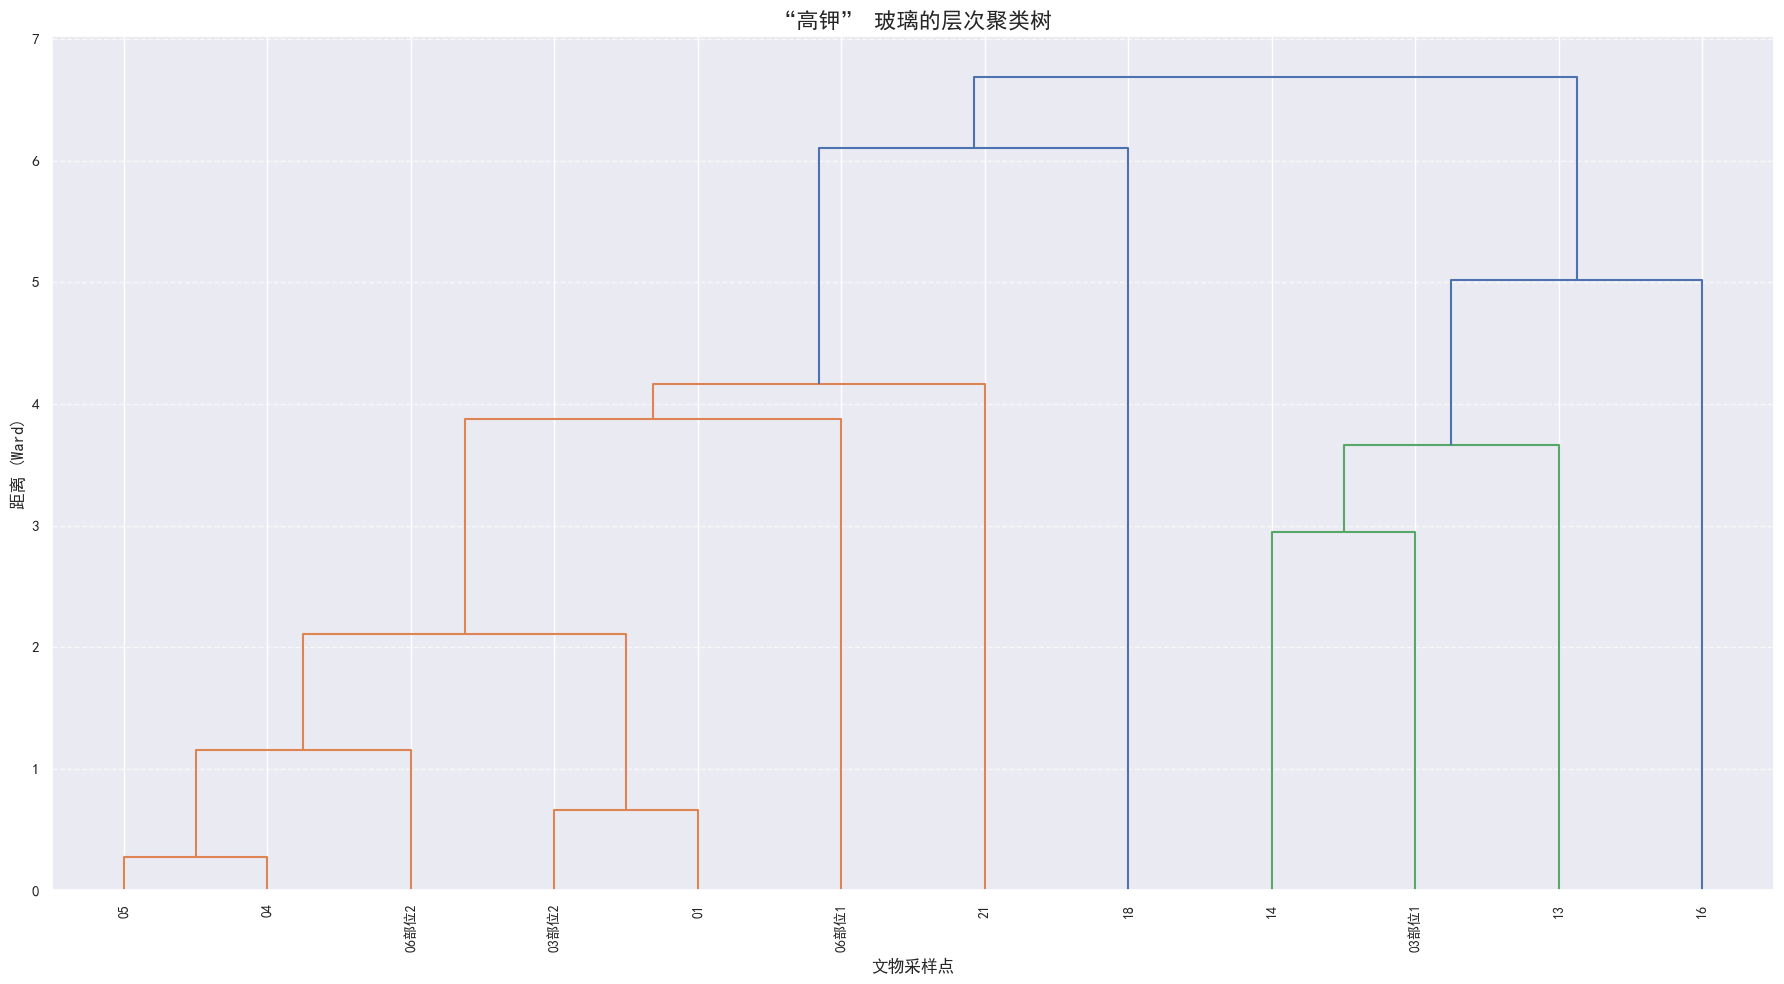


开始对 “铅钡” 玻璃进行层次聚类...
使用 7 个特征: 氧化钠(Na2O), 氧化钾(K2O), 氧化钙(CaO), 氧化镁(MgO), 氧化铝(Al2O3), 氧化铁(Fe2O3), 氧化铜(CuO)
样本数量: 23


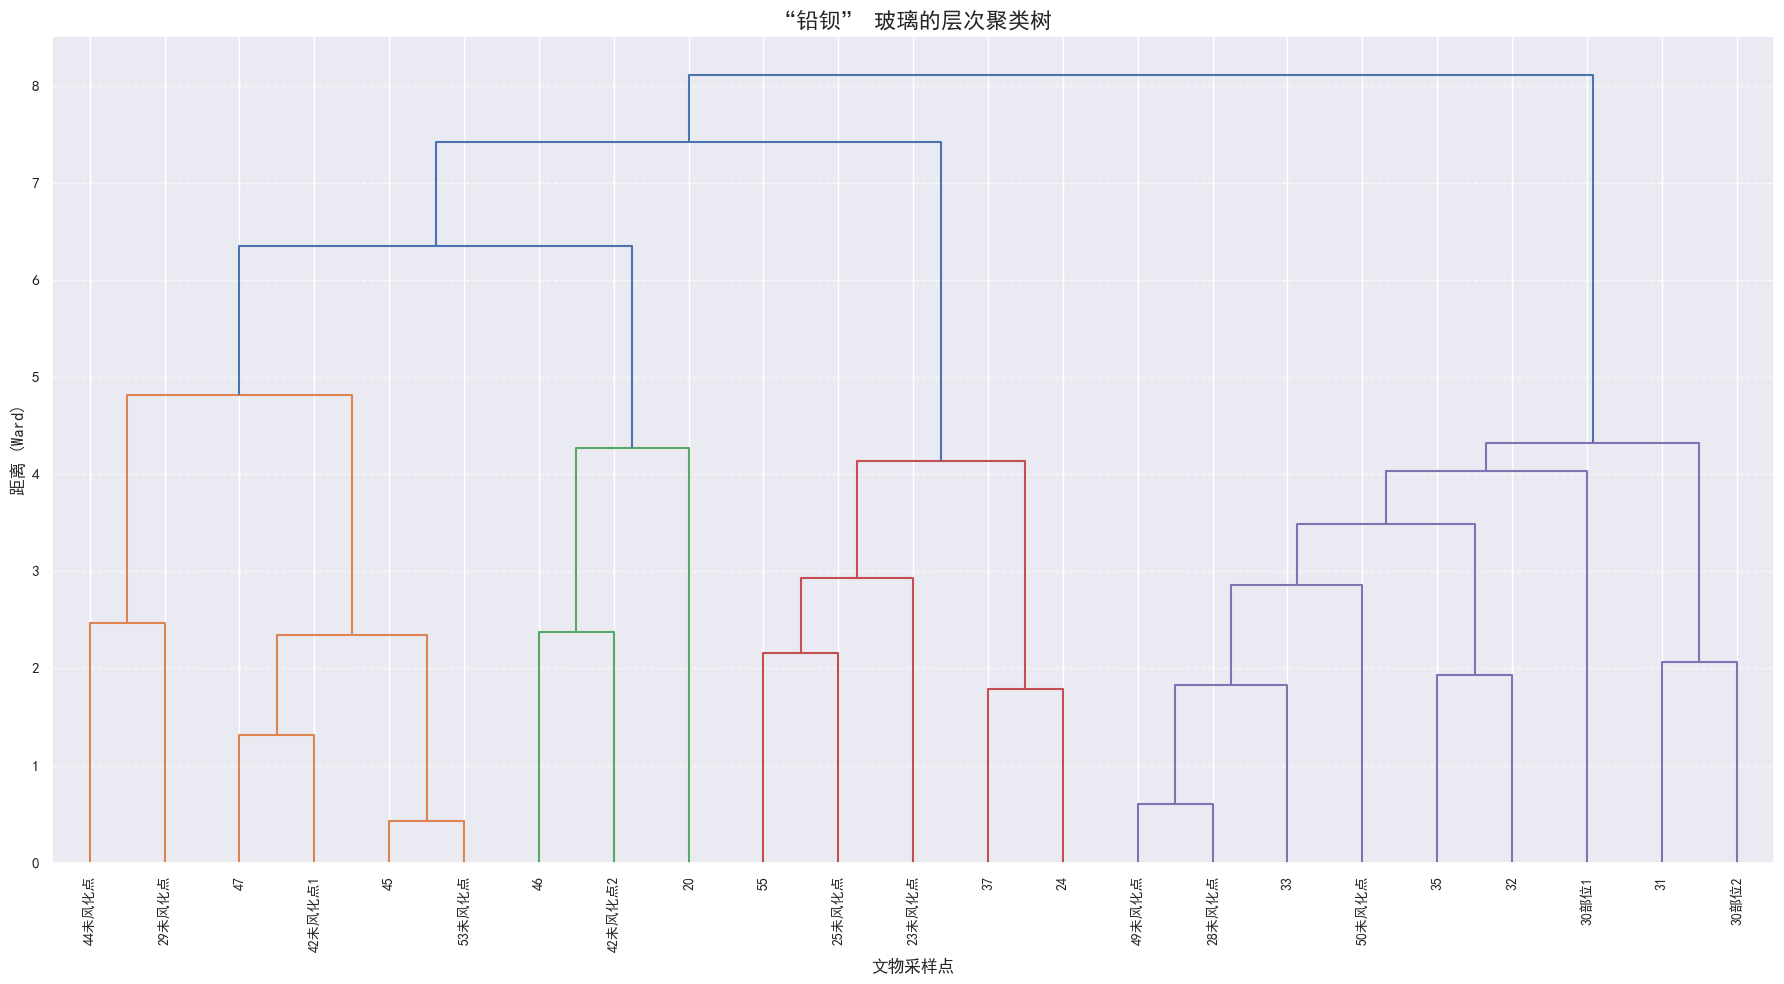

In [36]:
# 对 '高钾' 玻璃进行聚类
perform_hierarchical_clustering(analysis_df_pred, '高钾', clustering_features)

# 对 '铅钡' 玻璃进行聚类
perform_hierarchical_clustering(analysis_df_pred, '铅钡', clustering_features)

In [37]:
from scipy.cluster.hierarchy import fcluster

def analyze_feature_importance_for_clustering(data, glass_type, features, n_clusters):
    """
    分析层次聚类的特征重要性。
    
    参数:
    - data (pd.DataFrame): 包含所有样本的DataFrame。
    - glass_type (str): 要筛选的玻璃类型。
    - features (list): 用于聚类的化学成分列表。
    - n_clusters (int): 要划分的亚类数量。
    
    返回:
    - importance_df (pd.DataFrame): 按重要性排序的特征。
    - clustered_data (pd.DataFrame): 带有亚类标签的数据。
    """
    
    # 1. 筛选和准备数据
    type_data = data[data['类型'] == glass_type].copy()
    if type_data.empty:
        print(f"未找到类型为 '{glass_type}' 的数据。")
        return None, None
    
    # 检查并筛选可用特征
    available_features = [f for f in features if f in type_data.columns]
    if len(available_features) != len(features):
        print(f"警告: 部分特征在 '{glass_type}' 数据中缺失。将使用以下可用特征: {', '.join(available_features)}")
    
    if not available_features:
        print(f"错误: 在 '{glass_type}' 数据中，没有任何指定的特征可用于聚类。")
        return None, None

    features = available_features
    X_cluster = type_data[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)
    
    # 2. 执行聚类并获取亚类标签
    linked = linkage(X_scaled, method='ward', metric='euclidean')
    clusters = fcluster(linked, n_clusters, criterion='maxclust')
    type_data['亚类'] = clusters
    
    # 3. 计算F-比率
    feature_importance = []
    for feature in features:
        grand_mean = type_data[feature].mean()
        
        between_group_variance = sum(len(type_data[type_data['亚类'] == i]) * ((type_data[type_data['亚类'] == i][feature].mean() - grand_mean) ** 2) for i in range(1, n_clusters + 1))
        
        within_group_variance = sum(sum((type_data[type_data['亚类'] == i][feature] - type_data[type_data['亚类'] == i][feature].mean()) ** 2) for i in range(1, n_clusters + 1))
            
        if within_group_variance == 0:
            f_ratio = float('inf') if between_group_variance > 0 else 0
        else:
            f_ratio = between_group_variance / within_group_variance
            
        feature_importance.append({'化学成分': feature, 'F-比率': f_ratio})
        
    importance_df = pd.DataFrame(feature_importance).sort_values(by='F-比率', ascending=False)
    
    return importance_df, type_data


def visualize_clustering_with_key_features(clustered_data, key_features, glass_type):
    """
    使用最重要的特征可视化聚类结果。
    """
    n_key_features = len(key_features)
    if n_key_features < 2:
        print("至少需要2个关键特征才能进行可视化。")
        return

    plt.figure(figsize=(10, 8))
    
    if n_key_features >= 3:
        ax = plt.subplot(111, projection='3d')
        scatter = ax.scatter(
            clustered_data[key_features[0]], 
            clustered_data[key_features[1]], 
            clustered_data[key_features[2]], 
            c=clustered_data['亚类'], 
            cmap='viridis', s=60, alpha=0.8
        )
        ax.set_xlabel(key_features[0])
        ax.set_ylabel(key_features[1])
        ax.set_zlabel(key_features[2])
        plt.title(f'“{glass_type}” 玻璃亚类划分 - 3D视图', fontsize=16)
    else:
        ax = plt.subplot(111)
        scatter = ax.scatter(
            clustered_data[key_features[0]], 
            clustered_data[key_features[1]], 
            c=clustered_data['亚类'], 
            cmap='viridis', s=60, alpha=0.8
        )
        ax.set_xlabel(key_features[0])
        ax.set_ylabel(key_features[1])
        plt.title(f'“{glass_type}” 玻璃亚类划分 - 2D视图', fontsize=16)

    legend = ax.legend(*scatter.legend_elements(), title="亚类")
    ax.add_artist(legend)
    plt.grid(True)
    plt.show()


--- “高钾”玻璃亚类划分 (划分为 2 类) 的特征重要性 ---


,化学成分,F-比率
0,氧化钠(Na2O),2.856346
3,氧化镁(MgO),0.608416
4,氧化铝(Al2O3),0.440205
2,氧化钙(CaO),0.261376
1,氧化钾(K2O),0.172506
5,氧化铁(Fe2O3),0.089362
6,氧化铜(CuO),0.005299


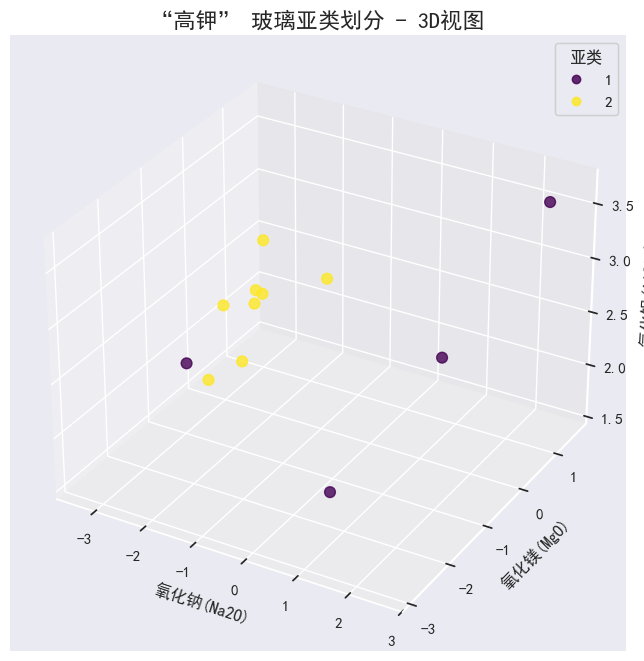



--- “铅钡”玻璃亚类划分 (划分为 3 类) 的特征重要性 ---


,化学成分,F-比率
4,氧化铝(Al2O3),1.544492
6,氧化铜(CuO),1.017512
0,氧化钠(Na2O),0.928586
2,氧化钙(CaO),0.387444
3,氧化镁(MgO),0.376020
5,氧化铁(Fe2O3),0.327406
1,氧化钾(K2O),0.304778


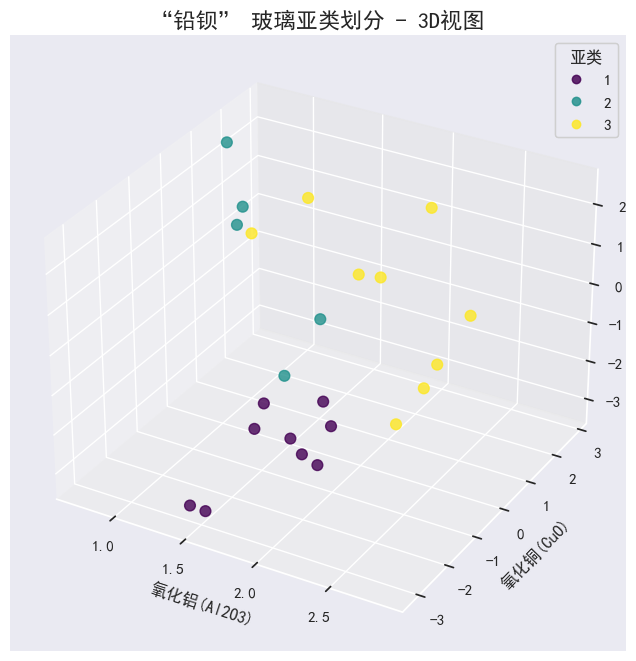

In [ ]:
# --- 分析 '高钾' 玻璃 ---
# 根据聚类树，尝试将 '高钾' 玻璃划分为 2 个亚类
n_clusters_gaojia = 2
gaojia_importance, gaojia_clustered = analyze_feature_importance_for_clustering(
    analysis_df_pred, '高钾', clustering_features, n_clusters_gaojia
)

if gaojia_importance is not None:
    print(f"--- “高钾”玻璃亚类划分 (划分为 {n_clusters_gaojia} 类) 的特征重要性 ---")
    display(gaojia_importance)
    
    # 可视化
    key_features_gaojia = gaojia_importance['化学成分'].head(3).tolist()
    visualize_clustering_with_key_features(gaojia_clustered, key_features_gaojia, '高钾')

print("\n" + "="*80 + "\n")

# --- 分析 '铅钡' 玻璃 ---
# 根据聚类树，尝试将 '铅钡' 玻璃划分为 3 个亚类
n_clusters_qianbei = 3
qianbei_importance, qianbei_clustered = analyze_feature_importance_for_clustering(
    analysis_df_pred, '铅钡', clustering_features, n_clusters_qianbei
)

if qianbei_importance is not None:
    print(f"--- “铅钡”玻璃亚类划分 (划分为 {n_clusters_qianbei} 类) 的特征重要性 ---")
    display(qianbei_importance)
    
    # 可视化
    key_features_qianbei = qianbei_importance['化学成分'].head(3).tolist()
    visualize_clustering_with_key_features(qianbei_clustered, key_features_qianbei, '铅钡')


In [42]:
def visualize_svm_subclass_results(svm_model, scaler, data, features, glass_type):
    """
    可视化SVM亚类划分的结果，支持2D和3D。
    """
    n_features = len(features)
    if n_features not in [2, 3]:
        print("可视化仅支持2或3个特征。")
        return

    X = data[features]
    y = data['亚类']
    
    plt.figure(figsize=(12, 9))
    
    # 绘制数据点
    if n_features == 3:
        ax = plt.subplot(111, projection='3d')
        scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], X.iloc[:, 2], c=y, cmap='viridis', s=60, alpha=0.8)
        ax.set_xlabel(features[0])
        ax.set_ylabel(features[1])
        ax.set_zlabel(features[2])
    else: # n_features == 2
        ax = plt.subplot(111)
        scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='viridis', s=60, alpha=0.8)
        ax.set_xlabel(features[0])
        ax.set_ylabel(features[1])

    plt.title(f'“{glass_type}” 玻璃亚类SVM划分可视化', fontsize=16)
    legend = ax.legend(*scatter.legend_elements(), title="亚类")
    ax.add_artist(legend)
    
    # 创建网格来绘制决策边界
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    
    if n_features == 3:
        z_min, z_max = X.iloc[:, 2].min() - 1, X.iloc[:, 2].max() + 1
        xx, yy, zz = np.meshgrid(np.linspace(x_min, x_max, 30),
                                 np.linspace(y_min, y_max, 30),
                                 np.linspace(z_min, z_max, 30))
    else:
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))

    # 获取原始空间的系数
    w_scaled = svm_model.coef_
    b_scaled = svm_model.intercept_
    w_original = w_scaled / scaler.scale_
    b_original = b_scaled - np.sum(w_scaled * scaler.mean_ / scaler.scale_, axis=1)

    # 绘制决策边界
    if n_features == 2:
        if len(svm_model.classes_) == 2: # 二分类
            Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w_original[0]) + b_original[0]
            Z = Z.reshape(xx.shape)
            ax.contour(xx, yy, Z, colors='k', levels=[0], alpha=0.7, linestyles=['-'])
        else: # 多分类 (OVR)
            Z = svm_model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
            Z = Z.reshape(xx.shape)
            ax.contourf(xx, yy, Z, cmap='viridis', alpha=0.2)

    if n_features == 3:
        # 对于3D，可视化平面比较复杂，这里我们只为每个OVR分类器画一个平面
        for i, class_label in enumerate(svm_model.classes_):
            w_o = w_original[i]
            b_o = b_original[i]
            
            # 平面方程: w0*x + w1*y + w2*z + b = 0
            # 解出 z: z = (-w0*x - w1*y - b) / w2
            if abs(w_o[2]) > 1e-6:
                plane_xx, plane_yy = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))
                plane_zz = (-w_o[0] * plane_xx - w_o[1] * plane_yy - b_o) / w_o[2]
                
                # 限制平面在数据范围内
                plane_zz = np.where((plane_zz >= z_min) & (plane_zz <= z_max), plane_zz, np.nan)
                
                ax.plot_surface(plane_xx, plane_yy, plane_zz, alpha=0.2, label=f'Plane for class {class_label}')

    plt.grid(True)
    plt.show()


In [43]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

def perform_subclass_svm_analysis(clustered_data, glass_type, svm_features):
    """
    对指定玻璃类型的亚类进行SVM分析，并计算分界函数。
    
    参数:
    - clustered_data (pd.DataFrame): 包含亚类标签的数据。
    - glass_type (str): 要分析的玻璃类型。
    - svm_features (list): 用于SVM分类的化学成分列表。
    """
    
    print(f"\n{'='*80}")
    print(f"  开始对 “{glass_type}” 玻璃的亚类进行SVM分析")
    print(f"{'='*80}")
    
    # 1. 准备数据
    svm_data = clustered_data.copy()
    
    # 检查特征是否存在
    available_features = [f for f in svm_features if f in svm_data.columns]
    if len(available_features) != len(svm_features):
        print(f"警告: 部分SVM特征缺失。将使用以下可用特征: {', '.join(available_features)}")
    if not available_features:
        print("错误: 没有可用的SVM特征。")
        return
    svm_features = available_features

    X = svm_data[svm_features]
    y = svm_data['亚类']
    
    n_subclasses = len(y.unique())
    print(f"亚类数量: {n_subclasses}")
    print(f"使用特征: {', '.join(svm_features)}")
    
    if n_subclasses < 2:
        print("亚类数量少于2，无法进行SVM分析。")
        return

    # 2. 数据标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3. 训练SVM模型
    svm_model = SVC(kernel='linear', decision_function_shape='ovr', random_state=42)
    svm_model.fit(X_scaled, y)
    
    y_pred = svm_model.predict(X_scaled)
    accuracy = accuracy_score(y, y_pred)
    print(f"\n模型在数据集上的准确率: {accuracy:.2%}")
    print("分类报告:")
    print(classification_report(y, y_pred, zero_division=0))

    # 4. 提取并转换分界函数
    w_scaled = svm_model.coef_
    b_scaled = svm_model.intercept_
    
    feature_means = scaler.mean_
    feature_stds = scaler.scale_
    
    w_original = w_scaled / feature_stds
    b_original = b_scaled - np.sum(w_scaled * feature_means / feature_stds, axis=1)
    
    print("\n--- 分界函数 (决策边界) ---")
    
    if n_subclasses == 2:
        w_o = w_original[0]
        b_o = b_original[0]
        equation = " + ".join([f"({w_o[i]:.4f} * {feat})" for i, feat in enumerate(svm_features)])
        print(f"分界函数 f(x) = {equation} + ({b_o:.4f})")
        
        class_0, class_1 = svm_model.classes_[0], svm_model.classes_[1]
        print(f"\n分类规则:")
        print(f"  • 如果 f(x) > 0, 则判定为亚类 {class_1}")
        print(f"  • 如果 f(x) < 0, 则判定为亚类 {class_0}")
        
    else:
        for i, class_label in enumerate(svm_model.classes_):
            w_o = w_original[i]
            b_o = b_original[i]
            equation = " + ".join([f"({w_o[j]:.4f} * {feat})" for j, feat in enumerate(svm_features)])
            print(f"\n亚类 {class_label} vs. 其他亚类的分界函数 f_{class_label}(x):")
            print(f"  f_{class_label}(x) = {equation} + ({b_o:.4f})")
        
        print("\n分类规则:")
        print("  对于一个新样本，计算其在所有分界函数上的值 (f_1(x), f_2(x), ...)。")
        print("  样本将被归类到函数值最大的那个亚类。")

    # 5. 可视化结果
    visualize_svm_subclass_results(svm_model, scaler, svm_data, svm_features, glass_type)

    print(f"\n{'='*80}\n")



  开始对 “高钾” 玻璃的亚类进行SVM分析
亚类数量: 2
使用特征: 氧化钠(Na2O), 氧化镁(MgO)

模型在数据集上的准确率: 100.00%
分类报告:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         8

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


--- 分界函数 (决策边界) ---
分界函数 f(x) = (-0.4914 * 氧化钠(Na2O)) + (0.7036 * 氧化镁(MgO)) + (-0.5652)

分类规则:
  • 如果 f(x) > 0, 则判定为亚类 2
  • 如果 f(x) < 0, 则判定为亚类 1


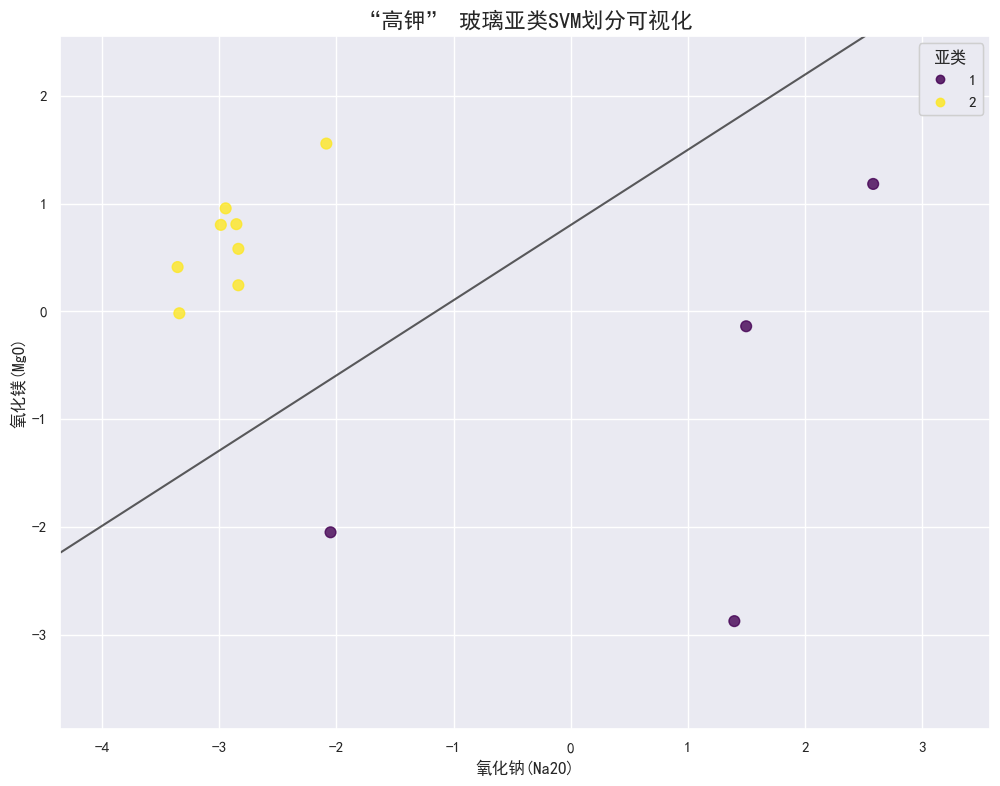




  开始对 “铅钡” 玻璃的亚类进行SVM分析
亚类数量: 3
使用特征: 氧化铜(CuO), 氧化铝(Al2O3), 氧化钠(Na2O)

模型在数据集上的准确率: 100.00%
分类报告:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         9

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23


--- 分界函数 (决策边界) ---

亚类 1 vs. 其他亚类的分界函数 f_1(x):
  f_1(x) = (-0.8676 * 氧化铜(CuO)) + (1.9003 * 氧化铝(Al2O3)) + (-0.0970 * 氧化钠(Na2O)) + (-2.3937)

亚类 2 vs. 其他亚类的分界函数 f_2(x):
  f_2(x) = (-0.5915 * 氧化铜(CuO)) + (-1.2996 * 氧化铝(Al2O3)) + (-0.5089 * 氧化钠(Na2O)) + (1.3869)

亚类 3 vs. 其他亚类的分界函数 f_3(x):
  f_3(x) = (0.0877 * 氧化铜(CuO)) + (-2.3588 * 氧化铝(Al2O3)) + (-0.1445 * 氧化钠(Na2O)) + (3.2709)

分类规则:
  对于一个新样本，计算其在所有分界函数上的值 (f_1(x), f_2(x), ...)。
  样本将被归类到函数值最大的那个亚类。


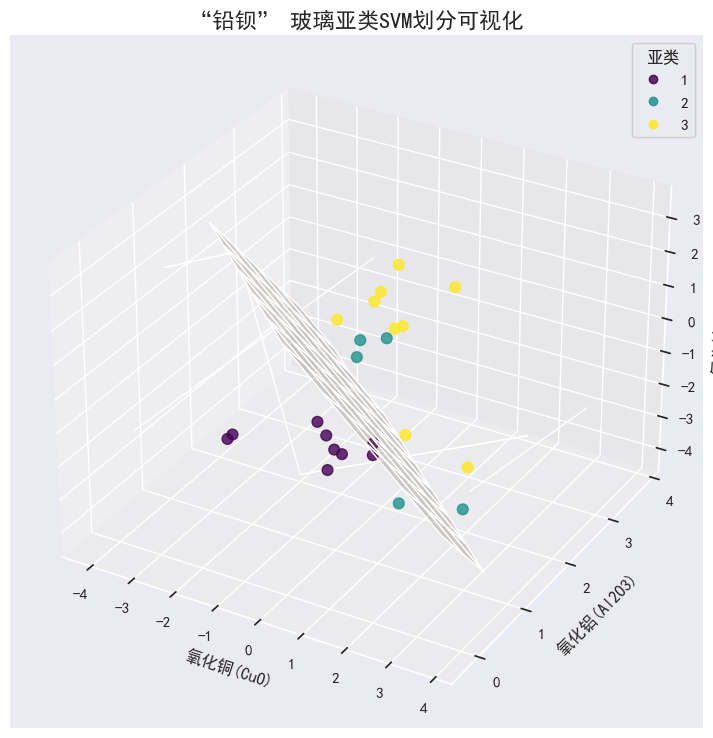

In [44]:
# --- 高钾玻璃的SVM亚类分析 ---
if 'gaojia_clustered' in locals() and gaojia_clustered is not None:
    gaojia_svm_features = ['氧化钠(Na2O)', '氧化镁(MgO)']
    perform_subclass_svm_analysis(gaojia_clustered, '高钾', gaojia_svm_features)

# --- 铅钡玻璃的SVM亚类分析 ---
if 'qianbei_clustered' in locals() and qianbei_clustered is not None:
    qianbei_svm_features = ['氧化铜(CuO)', '氧化铝(Al2O3)', '氧化钠(Na2O)']
    perform_subclass_svm_analysis(qianbei_clustered, '铅钡', qianbei_svm_features)
